In [1]:
import os
import re
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import pyNeuroDAP as ndap

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Multi-session analysis

Each neuron: laser_mod_index <--> left_right_tone_index, left_right_lick_index, reward_index

- tone: 25 ms
- reward is delivered as soon as the first selection lick is detected
- ENL: 1500 + np.ranodom(0,500)

**How pooling works here.** Sorted units are session-scoped, so every quantity is
computed *within* a session and only then combined:

| section | computed per session | pooled by |
|---|---|---|
| 2, 2.3 | one scalar per unit (modulation index, GLM kernel weight) | concatenating units into one long vector, indexed by `units_table` |
| 3.1, 4 | a time course in that session's own arbitrary units | z-scoring per session, then mean +/- SEM across sessions |
| 3.2, 5 | a PC / latent space that is not comparable between fits | one panel per session, never averaged |

Nothing is pooled across sessions *inside* a model fit. Each session keeps its own
laser timing, so a session whose laser fires at a different onset still gets the right
window.

## 1. Load the sessions

In [2]:
# Select any number of session folders. The native macOS picker takes several at once
# (cmd-click); the tkinter fallback adds them one at a time, or every subfolder of a
# parent folder.
default_path = r"/Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2"

session_folders = ndap.select_sessions("Select session folders to pool",
                                       default_path=default_path)

# Hard loading: paste paths here to skip the GUI
# session_folders = [
#     rf"/Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_3_260807ok_5mWBlue_500ms_080726001",
#     rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001",
#     rf"/Volumes/MICROSCOPE/Paolo/FromFor/ForShun_InVivo/Rec_Upstream_DCN_1_250323_5mW_500ms_500delay_032325001",
# ]

if not session_folders:
    raise RuntimeError("No sessions selected - re-run this cell")

print(f"Selected {len(session_folders)} session(s):")
for folder in session_folders:
    print(f"  - {os.path.basename(folder)}")

Selected 11 session(s):
  - Rec_Upstream_DCN_1_250318_CT_merged
  - Rec_Upstream_DCN_1_250325_032525001
  - Rec_Upstream_DCN_1_250327ok_CT_032725001
  - Rec_Upstream_DCN_3_260802_080226001
  - Rec_Upstream_DCN_3_260807ok_5mWBlue_500ms_080726001
  - Rec_Upstream_DCN_1_250320_1mW_500ms_0delay_032025001
  - Rec_Upstream_DCN_1_250322_5mW_50ms_0delay_032225001
  - Rec_Upstream_DCN_3_260808_CT_080826001
  - Rec_Upstream_DCN_3_260811_5mWBlue_500ms_081126001
  - Rec_Upstream_DCN_3_260812_CT_081226001
  - Rec_Upstream_DCN_3_260814_CT_081426001


In [3]:
# Which results folder to load inside each session: 'newest', or an explicit name
# e.g. 'results-260913-good' (that name then has to exist in every session).
results_folder_mode = 'newest'


def resolve_results_folder(base_folder, mode='newest'):
    """
    Pick a results folder inside base_folder.

    mode='newest' takes the most recent results-YYMMDD[-tag] folder, ranked by
    the date in the folder name and then by modification time (so same-day runs
    with different unit selections resolve to the one written last). Any other
    value is treated as an explicit folder name.

    Only folders holding both data.h5 and aligned_spikes.h5 are considered, so
    an interrupted run is never picked.
    """
    required = ('data.h5', 'aligned_spikes.h5')

    if mode != 'newest':
        folder = os.path.join(base_folder, mode)
        if not os.path.isdir(folder):
            raise FileNotFoundError(f"Results folder not found: {folder}")
        return folder

    candidates = [
        d for d in os.listdir(base_folder)
        if d.startswith('results-')
        and all(os.path.isfile(os.path.join(base_folder, d, f)) for f in required)
    ]
    if not candidates:
        available = sorted(d for d in os.listdir(base_folder) if d.startswith('results-'))
        raise FileNotFoundError(
            f"No complete results folder (needs {' + '.join(required)}).\n"
            f"results-* folders present: {available or 'none'}"
        )

    def sort_key(name):
        match = re.match(r'results-(\d{6})', name)
        date = match.group(1) if match else ''
        return (date, os.path.getmtime(os.path.join(base_folder, name)))

    return os.path.join(base_folder, max(candidates, key=sort_key))


def load_session(base_folder, mode='newest'):
    """
    Load one session into a self-contained dict.

    Every analysis function below reads only from this dict and never from globals,
    which is what lets the same body run for one session or twenty.
    """
    results_folder = resolve_results_folder(base_folder, mode)

    data_path = os.path.join(results_folder, 'data.h5')
    data = ndap.load_session_data(data_path)
    trial_table = ndap.load_dataframe(data_path, key='trial_table')
    metadata = data['metadata']

    spikes_path = os.path.join(results_folder, 'aligned_spikes.h5')
    aligned_spikes = ndap.load_aligned_spikes(spikes_path)

    time_range = tuple(map(float, metadata['time_range'].strip('()').split(',')))
    bin_size = float(metadata['bin_size'])

    aligned_trial_start = aligned_spikes['trial_start']
    # .shape on the lazy dataset, so this does not read the whole array
    n_units = int(aligned_trial_start[next(iter(aligned_trial_start))]['rate'].shape[0])

    # Laser timing comes from the session's own behavior files (see
    # ndap.get_laser_timing for the source priority and its rationale)
    laser_timing = ndap.get_laser_timing(session_folder=base_folder, trial_table=trial_table)
    has_laser = bool(laser_timing['has_laser'])

    return dict(
        session_id=os.path.basename(base_folder),
        base_folder=base_folder,
        results_folder=results_folder,
        spikes_path=spikes_path,
        data=data,
        aligned_spikes=aligned_spikes,
        trial_table=trial_table,
        event_times=data['event_times'],
        metadata=metadata,
        aligned_trial_start=aligned_spikes['trial_start'],
        aligned_choice_lick=aligned_spikes['choice_lick'],
        aligned_second_lick=aligned_spikes['second_lick'],
        aligned_last_lick=aligned_spikes['last_lick'],
        time_range=time_range,
        bin_size=bin_size,
        xaxis=ndap.get_time_axis(time_range, bin_size_ms=bin_size),
        laser_timing=laser_timing,
        has_laser=has_laser,
        # a control session keeps placeholders so every window stays defined
        laser_onset=float(laser_timing['laser_onset']) if has_laser else 0.0,
        laser_duration=float(laser_timing['laser_duration']) if has_laser else 0.5,
        laser_source=laser_timing['onset_source'] or 'not detected',
        n_units=n_units,
        n_trials=len(trial_table),
    )


# ---- load every session, skipping the ones that cannot be pooled ----
sessions, skipped = [], []
reference = None          # (bin_size, time_range) of the first session that loads

for folder in tqdm(session_folders, desc='loading'):
    session_id = os.path.basename(folder)
    try:
        sess = load_session(folder, results_folder_mode)
    except Exception as err:
        skipped.append((session_id, f'{type(err).__name__}: {err}'))
        continue

    # Every pooled time-resolved figure stacks arrays on one shared xaxis, so bin size
    # and time range have to agree. They are per-session metadata written by
    # analyze_sessions_forPlexon.py, and nothing forces two sessions to match.
    signature = (sess['bin_size'], sess['time_range'])
    if reference is None:
        reference = signature
    elif signature != reference:
        skipped.append((session_id, f"bin/range {signature[0]:.0f}ms {signature[1]} != "
                                    f"reference {reference[0]:.0f}ms {reference[1]}"))
        ndap.close_loaded(sess['data'])
        ndap.close_loaded(sess['aligned_spikes'])
        continue

    sessions.append(sess)

if not sessions:
    raise RuntimeError(f"No session could be loaded: {skipped}")

# S1, S2, ... - a short handle for the dense per-unit tables and figure labels
for i, s in enumerate(sessions):
    s['tag'] = f'S{i + 1}'

bin_size, time_range = reference
xaxis = sessions[0]['xaxis']


def pool(per_session, key):
    """Concatenate one per-unit vector across sessions, in units_table order"""
    return np.concatenate([np.asarray(per_session[s['session_id']][key], dtype=float).ravel()
                           for s in sessions])

loading:   0%|          | 0/11 [00:00<?, ?it/s]

Analysis data loaded for session: /Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_1_250318_CT_merged/results-260915-good_excellent_mua/data.h5


loading:   9%|▉         | 1/11 [00:09<01:36,  9.67s/it]

Aligned spikes loaded from /Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_1_250318_CT_merged/results-260915-good_excellent_mua/aligned_spikes.h5 (lazy=True)
Analysis data loaded for session: /Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_1_250325_032525001/results-260915-good_excellent_mua/data.h5


loading:  18%|█▊        | 2/11 [00:16<01:09,  7.76s/it]

...

Aligned spikes loaded from /Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_3_260811_5mWBlue_500ms_081126001/results-260915-good_excellent_mua/aligned_spikes.h5 (lazy=True)
Analysis data loaded for session: /Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_3_260812_CT_081226001/results-260915-good_excellent_mua/data.h5


loading:  91%|█████████ | 10/11 [01:23<00:12, 12.31s/it]

Aligned spikes loaded from /Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_3_260812_CT_081226001/results-260915-good_excellent_mua/aligned_spikes.h5 (lazy=True)
Analysis data loaded for session: /Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_3_260814_CT_081426001/results-260915-good_excellent_mua/data.h5


loading: 100%|██████████| 11/11 [01:36<00:00,  8.79s/it]

Aligned spikes loaded from /Volumes/Neurobio/MICROSCOPE/Paolo/FromFor/ForShun_Invivo2/Rec_Upstream_DCN_3_260814_CT_081426001/results-260915-good_excellent_mua/aligned_spikes.h5 (lazy=True)


In [4]:
# ---- what was loaded ----
summary = pd.DataFrame([{
    'tag': s['tag'],
    'session_id': s['session_id'],
    'results': os.path.basename(s['results_folder']),
    'units': s['n_units'],
    'trials': s['n_trials'],
    'laser_trials': int(s['laser_timing']['n_laser_trials']) if s['has_laser'] else 0,
    'onset_s': round(s['laser_onset'], 4) if s['has_laser'] else np.nan,
    'dur_s': round(s['laser_duration'], 3) if s['has_laser'] else np.nan,
    'units_from': s['metadata'].get('unit_selection', 'unknown'),
} for s in sessions])

print(f"Loaded {len(sessions)} session(s), {int(summary['units'].sum())} units total, "
      f"bin {bin_size:.0f} ms, time range {time_range} s")
print(summary.to_string(index=False))

n_no_laser = int((summary['laser_trials'] == 0).sum())
if n_no_laser:
    print(f"\n{n_no_laser} session(s) have no laser trials. Their units still contribute to "
          f"tone/choice/motor/reward; every laser metric is NaN for them, so they drop out "
          f"of the laser figures on their own.")

if skipped:
    print()
    for session_id, reason in skipped:
        print(f"  ! skipped {session_id}: {reason}")
    print("  (a bin/range mismatch means re-running analyze_sessions_forPlexon.py on that "
          "session with the settings printed above)")

for s in sessions:
    for warning in s['laser_timing']['warnings']:
        print(f"  ! {s['session_id']}: {warning}")

# ---- one row per pooled unit: the index of every pooled vector below ----
rows = []
for s in sessions:
    info = s['data'].get('unit_info', {})
    ids = [int(u) for u in info['unit_ids']] if 'unit_ids' in info else []
    labels = [l.decode() if isinstance(l, bytes) else str(l)
              for l in info.get('unit_labels', [])]
    for row in range(s['n_units']):
        rows.append({'session_id': s['session_id'], 'tag': s['tag'], 'row': row,
                     'unit_id': ids[row] if len(ids) == s['n_units'] else -1,
                     'label': labels[row] if len(labels) == s['n_units'] else 'unknown'})
units_table = pd.DataFrame(rows)
session_of_unit = units_table['session_id'].values     # for colouring pooled figures
tag_of_unit = units_table['tag'].values

print(f"\nunits_table: {len(units_table)} pooled units")
print(units_table.groupby('session_id', sort=False).size().to_string())


def unit_label(pooled_index):
    """Short 'S1#7 (good)' handle for one pooled unit; summary maps the tag to the id"""
    r = units_table.iloc[pooled_index]
    return f"{r['tag']}#{r['row']} ({r['label']})"

Loaded 9 session(s), 392 units total, bin 25 ms, time range (-1.0, 5.0) s
tag                                           session_id                           results  units  trials  laser_trials  onset_s  dur_s         units_from
 S1                  Rec_Upstream_DCN_1_250318_CT_merged results-260915-good_excellent_mua     66     277             0      NaN    NaN good_excellent_mua
 S2                  Rec_Upstream_DCN_1_250325_032525001 results-260915-good_excellent_mua     66     306             0      NaN    NaN good_excellent_mua
 S3                  Rec_Upstream_DCN_3_260802_080226001 results-260915-good_excellent_mua     70     268             0      NaN    NaN good_excellent_mua
 S4 Rec_Upstream_DCN_1_250320_1mW_500ms_0delay_032025001 results-260915-good_excellent_mua     18     299            91   0.0018   0.50 good_excellent_mua
 S5  Rec_Upstream_DCN_1_250322_5mW_50ms_0delay_032225001 results-260915-good_excellent_mua     33     318            77   0.0018   0.05 good_excellent_

## 2. Get modulation index

- Tone
- Choice lick (left vs right encoding)
- reward
- laser

In [5]:
mod_index_type = 'norm'
mod_verbose = False        # True also prints each session's own top-10 table

# ####################### Window definitions ########################
# Only the response-window *lengths* below are analysis choices, and they all live in
# one place. Everything timed by the recording (bin size, laser onset and duration, the
# artifact bin) is read from each session, so sessions with different laser timing each
# get their own laser window.

tone_window   = (0, 50)
choice_window = (0, 75)
motor_window  = (0, 100)
reward_window = (0, 200)
motor_ref_window = (150, 250)     # late reference for the motor index
tone_ref_window  = (-75, -25)     # pre-tone reference
baseline_window  = (-500, 0)      # pre-trial, within time_range

print(f"windows (ms): tone {tone_window}, choice {choice_window}, motor {motor_window}, "
      f"reward {reward_window}, baseline {baseline_window}")

# Behavioural timing per session, for judging whether those lengths fit
for s in sessions:
    parts = []
    for col, label in [('FirstLickLatency', 'first lick'), ('LickDuration', 'lick bout'),
                       ('TimeDelta', 'trial')]:
        if col in s['trial_table'].columns:
            v = s['trial_table'][col].dropna()
            if len(v):
                parts.append(f"{label} {v.median():.3f}s")
    print(f"  {s['tag']:>3s} {s['session_id']}: median " + ", ".join(parts))


from scipy.stats import mannwhitneyu


def auroc_p(a, b):
    """
    AUROC and its Mann-Whitney p from the finite trials only.

    AUROC is the probability that a random trial from a exceeds one from b (ties count
    a half); 0.5 means the two are indistinguishable. Being rank-based it cannot
    saturate the way a ratio index does.
    """
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if len(a) < 2 or len(b) < 2:
        return np.nan, np.nan
    res = mannwhitneyu(a, b, alternative='two-sided')
    return res.statistic / (len(a) * len(b)), res.pvalue


def stack_trials(sess, want_laser, resp_mask, base_mask):
    """
    Per-trial response and baseline rates for every unit, plus each trial's first-lick
    latency, in one matching order.

    Going through event_times['trial_indices'] rather than combine_rates is what keeps
    the rate columns aligned with the trial-table rows, which the lick-controlled
    comparison needs.

    Returns (resp, base, latency) with shapes (units, trials), (units, trials), (trials,)
    """
    rates, bases, lats = [], [], []
    has_latency = 'FirstLickLatency' in sess['trial_table'].columns
    for cond, idx in sess['event_times']['trial_indices'].items():
        if ('laser' in cond) != want_laser:
            continue
        idx = np.asarray(idx, dtype=int)
        if not len(idx):
            continue
        rate = np.asarray(sess['aligned_trial_start'][cond]['rate'])
        rates.append(np.nanmean(rate[:, :, resp_mask], axis=2))
        bases.append(np.nanmean(rate[:, :, base_mask], axis=2))
        lats.append(sess['trial_table'].iloc[idx]['FirstLickLatency'].values if has_latency
                    else np.full(len(idx), np.nan))
    if not rates:
        return (np.empty((sess['n_units'], 0)), np.empty((sess['n_units'], 0)), np.empty(0))
    return (np.concatenate(rates, axis=1), np.concatenate(bases, axis=1),
            np.concatenate(lats).astype(float))


MOD_RATIO_KEYS = ['tone', 'choice', 'motor', 'reward', 'laser']
MOD_LASER_KEYS = ['laser_interaction_hz', 'laser_auroc', 'laser_pvalue', 'task_index',
                  'laser_index_lickfree', 'laser_auroc_lickfree', 'laser_p_lickfree',
                  'n_lickfree_laser', 'n_lickfree_control']


def session_mod_indices(sess, verbose=False):
    """
    Every per-unit modulation index for one session.

    Ratio indices (type='norm') contrast the mean rate over trials and bins in window A
    against window B: (A - B) / (A + B), in [-1, 1]. Tone and Motor compare a response
    window against a reference window *within the same trials*; Choice, Reward and Laser
    compare *two conditions in the same window*, so a positive Laser index means "more
    than control", not "more than baseline".

    The laser family adds three measures the ratio index cannot give:
      interaction - (laser change from baseline) - (control change from baseline), in Hz,
                    so a +14 Hz change on an active unit no longer scores below +1 Hz on
                    a near-silent one
      AUROC / p   - per-trial separability, which cannot saturate
      *_lickfree  - the same three on trials with no lick inside the laser window, since
                    laser trials lick later and less and the window overlaps the lick

    Returns {name: (n_units,) array}. A session without laser trials returns NaN for
    every laser key, so its units still contribute to the other four indices.
    """
    bs, xa = sess['bin_size'], sess['xaxis']
    laser_onset, laser_duration = sess['laser_onset'], sess['laser_duration']
    # Laser on/offset produce an electrical artifact that lands in the onset bin, so
    # every laser window starts one full bin after the event.
    artifact_skip_ms = float(bs)
    laser_window = (artifact_skip_ms, laser_duration * 1000)
    n_units = sess['n_units']

    def windowed(aligned, keys, window, onset=0.0):
        return ndap.get_window(ndap.combine_rates(aligned, key=keys), onset_time=onset,
                               window_ms=window, bin_size_ms=bs, xaxis=xa)

    out = {}

    # ----------------------------- Tone -----------------------------
    out['tone'] = ndap.get_mod_index(
        windowed(sess['aligned_trial_start'], ['control'], tone_window),
        windowed(sess['aligned_trial_start'], ['control'], tone_ref_window),
        type=mod_index_type)

    # ------------------- Choice (left vs right encoding) -------------------
    out['choice'] = ndap.get_mod_index(
        windowed(sess['aligned_choice_lick'], ['left', 'control'], choice_window),
        windowed(sess['aligned_choice_lick'], ['right', 'control'], choice_window),
        type=mod_index_type)

    # ----------------------------- Motor -----------------------------
    out['motor'] = ndap.get_mod_index(
        windowed(sess['aligned_last_lick'], ['control'], motor_window),
        windowed(sess['aligned_last_lick'], ['control'], motor_ref_window),
        type=mod_index_type)

    # ----------------------------- Reward -----------------------------
    # CAVEAT, inherited from the single-session notebook: combine_rates matches
    # condition names by substring, and 'nonreward_left_control' contains 'reward', so
    # key=['reward', 'control'] selects ALL FOUR control conditions, not the rewarded
    # ones. Window A is therefore every control trial and window B is the non-rewarded
    # ones, which still has the right sign but a diluted magnitude. Kept as-is so these
    # numbers stay comparable with the single-session notebook; use the GLM reward
    # kernel (signed by RMI, so unaffected) for the clean contrast.
    out['reward'] = ndap.get_mod_index(
        windowed(sess['aligned_second_lick'], ['reward', 'control'], reward_window),
        windowed(sess['aligned_second_lick'], ['nonreward', 'control'], reward_window),
        type=mod_index_type)

    # ----------------------------- Laser -----------------------------
    # laser vs control in the same window (NOT response vs own baseline)
    if sess['has_laser']:
        out['laser'] = ndap.get_mod_index(
            windowed(sess['aligned_trial_start'], ['laser'], laser_window, laser_onset),
            windowed(sess['aligned_trial_start'], ['control'], laser_window, laser_onset),
            type=mod_index_type)
    else:
        out['laser'] = np.full(n_units, np.nan)

    out = {k: np.asarray(ndap.convert_dask_to_numpy(v), dtype=float).ravel()
           for k, v in out.items()}

    # ------------------- Robust laser statistics -------------------
    for key in MOD_LASER_KEYS:
        out[key] = np.full(n_units, np.nan)

    if sess['has_laser'] and 'trial_indices' in sess['event_times']:
        resp_mask = ((xa >= laser_onset + artifact_skip_ms / 1000)
                     & (xa <= laser_onset + laser_duration))
        base_mask = (xa >= baseline_window[0] / 1000) & (xa < baseline_window[1] / 1000)

        L_resp, L_base, L_lat = stack_trials(sess, True, resp_mask, base_mask)
        C_resp, C_base, C_lat = stack_trials(sess, False, resp_mask, base_mask)

        # no lick before the laser window ends
        lick_free_cut = laser_onset + laser_duration
        free = lambda lat: (~np.isfinite(lat)) | (lat >= lick_free_cut)
        mL, mC = free(L_lat), free(C_lat)
        out['n_lickfree_laser'] = np.full(n_units, int(mL.sum()))
        out['n_lickfree_control'] = np.full(n_units, int(mC.sum()))
        enough_lickfree = mL.sum() >= 5 and mC.sum() >= 5

        for u in range(n_units):
            out['laser_interaction_hz'][u] = ((np.nanmean(L_resp[u]) - np.nanmean(L_base[u]))
                                              - (np.nanmean(C_resp[u]) - np.nanmean(C_base[u])))
            out['laser_auroc'][u], out['laser_pvalue'][u] = auroc_p(L_resp[u], C_resp[u])
            out['task_index'][u] = ((np.nanmean(C_resp[u]) - np.nanmean(C_base[u]))
                                    / (np.nanmean(C_resp[u]) + np.nanmean(C_base[u]) + 1e-12))
            if enough_lickfree:
                L, C = L_resp[u][mL], C_resp[u][mC]
                out['laser_index_lickfree'][u] = ((np.nanmean(L) - np.nanmean(C))
                                                  / (np.nanmean(L) + np.nanmean(C) + 1e-12))
                (out['laser_auroc_lickfree'][u],
                 out['laser_p_lickfree'][u]) = auroc_p(L, C)

        if verbose:
            print(f"\n{sess['session_id']}: laser window "
                  f"{laser_onset + artifact_skip_ms/1000:.3f}-{laser_onset + laser_duration:.3f} s, "
                  f"{int(mL.sum())}/{L_resp.shape[1]} laser and {int(mC.sum())}/{C_resp.shape[1]} "
                  f"control trials lick-free")
            print(f"  {'unit':>4s} {'ratio':>7s} {'interact':>9s} {'AUROC':>6s} {'p':>8s} "
                  f"{'task':>6s} {'lf idx':>7s} {'lf p':>8s}")
            for u in np.argsort(-np.abs(np.nan_to_num(out['laser_interaction_hz'])))[:10]:
                print(f"  {u:4d} {out['laser'][u]:+7.3f} {out['laser_interaction_hz'][u]:+8.2f}Hz "
                      f"{out['laser_auroc'][u]:6.3f} {out['laser_pvalue'][u]:8.4f} "
                      f"{out['task_index'][u]:+6.2f} {out['laser_index_lickfree'][u]:+7.3f} "
                      f"{out['laser_p_lickfree'][u]:8.4f}")
    elif sess['has_laser']:
        print(f"  ! {sess['session_id']}: no trial_indices in this results folder, so the "
              f"per-trial laser statistics are unavailable (the ratio index still works)")

    return out


# ---- run per session, then concatenate units ----
per_session_mod = {}
for s in tqdm(sessions, desc='modulation indices'):
    per_session_mod[s['session_id']] = session_mod_indices(s, verbose=mod_verbose)

mod = {k: pool(per_session_mod, k) for k in MOD_RATIO_KEYS + MOD_LASER_KEYS}

# the familiar single-session names now point at the pooled vectors
tone_mod_index       = mod['tone']
choice_mod_index     = mod['choice']
motor_mod_index      = mod['motor']
reward_mod_index     = mod['reward']
laser_mod_index      = mod['laser']
laser_interaction_hz = mod['laser_interaction_hz']
laser_auroc          = mod['laser_auroc']
laser_pvalue         = mod['laser_pvalue']
task_index           = mod['task_index']

windows (ms): tone (0, 50), choice (0, 75), motor (0, 100), reward (0, 200), baseline (-500, 0)
   S1 Rec_Upstream_DCN_1_250318_CT_merged: median first lick 0.333s, lick bout 1.077s, trial 4.846s
   S2 Rec_Upstream_DCN_1_250325_032525001: median first lick 0.266s, lick bout 1.479s, trial 4.826s
   S3 Rec_Upstream_DCN_3_260802_080226001: median first lick 0.119s, lick bout 1.076s, trial 4.148s
   S4 Rec_Upstream_DCN_1_250320_1mW_500ms_0delay_032025001: median first lick 0.244s, lick bout 1.343s, trial 4.540s
   S5 Rec_Upstream_DCN_1_250322_5mW_50ms_0delay_032225001: median first lick 0.255s, lick bout 1.575s, trial 5.136s
   S6 Rec_Upstream_DCN_3_260808_CT_080826001: median first lick 0.114s, lick bout 1.357s, trial 4.406s
   S7 Rec_Upstream_DCN_3_260811_5mWBlue_500ms_081126001: median first lick 0.185s, lick bout 1.541s, trial 4.837s
   S8 Rec_Upstream_DCN_3_260812_CT_081226001: median first lick 0.091s, lick bout 1.500s, trial 4.537s
   S9 Rec_Upstream_DCN_3_260814_CT_081426001: media

modulation indices:   0%|          | 0/9 [00:00<?, ?it/s]

Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_control', 'nonreward_right_control']


modulation indices:  11%|█         | 1/9 [00:03<00:24,  3.03s/it]

Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']


...

Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']


modulation indices:  89%|████████▉ | 8/9 [01:26<00:15, 15.35s/it]

Combining 2 conditions: ['nonreward_left_control', 'nonreward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']
Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']


modulation indices: 100%|██████████| 9/9 [01:55<00:00, 12.84s/it]

Combining 2 conditions: ['nonreward_left_control', 'nonreward_right_control']


In [6]:
def describe(u):
    """Put one unit's laser effect in the context of what the task alone does"""
    if not np.isfinite(laser_pvalue[u]) or laser_pvalue[u] >= 0.05:
        return 'not significant'
    direction = 'increase' if laser_interaction_hz[u] > 0 else 'decrease'
    if task_index[u] < -0.2:
        return f'task-suppressed, laser {"relieves" if laser_interaction_hz[u] > 0 else "deepens"} it'
    if task_index[u] > 0.2:
        return f'task-excited, laser {direction}s it'
    return f'laser-driven {direction}'


# ---- per-session summary ----
print("Laser effect per session (Mann-Whitney on per-trial rates):")
for s in sessions:
    m = per_session_mod[s['session_id']]
    if not s['has_laser']:
        print(f"  {s['tag']:>3s} {s['session_id']}: no laser trials")
        continue
    print(f"  {s['tag']:>3s} {s['session_id']}: {int(np.nansum(m['laser_pvalue'] < 0.05)):3d}/"
          f"{s['n_units']:3d} units p<0.05 | window "
          f"{s['laser_onset'] + s['bin_size']/1000:.3f}-{s['laser_onset'] + s['laser_duration']:.3f} s "
          f"| lick-free {int(m['n_lickfree_laser'][0])}L/{int(m['n_lickfree_control'][0])}C")

# ---- pooled table, strongest laser effects first ----
n_laser_units = int(np.isfinite(laser_pvalue).sum())
print(f"\nPooled {len(units_table)} units from {len(sessions)} session(s); "
      f"{int(np.nansum(laser_pvalue < 0.05))}/{n_laser_units} testable units reach p<0.05 "
      f"(ranking the rest is noise)")
print(f"{'pooled':>6s} {'unit':>12s} {'ratio':>7s} {'interact':>9s} {'AUROC':>6s} "
      f"{'p':>8s} {'task':>6s} {'lf idx':>7s} {'lf p':>8s}  interpretation")
for u in np.argsort(-np.abs(np.nan_to_num(laser_interaction_hz)))[:15]:
    if not np.isfinite(laser_interaction_hz[u]):
        continue
    r = units_table.iloc[u]
    print(f"{u:6d} {r['tag'] + '#' + str(r['row']):>12s} "
          f"{laser_mod_index[u]:+7.3f} {laser_interaction_hz[u]:+8.2f}Hz {laser_auroc[u]:6.3f} "
          f"{laser_pvalue[u]:8.4f} {task_index[u]:+6.2f} "
          f"{mod['laser_index_lickfree'][u]:+7.3f} {mod['laser_p_lickfree'][u]:8.4f}  {describe(u)}")
print("  lf = licking held constant; an effect that survives there is not explained by "
      "the lick difference between laser and control trials")

# ---- top 5 by each index, with the session each unit came from ----
for name in MOD_RATIO_KEYS:
    values = mod[name]
    order = np.argsort(values)
    order = order[np.isfinite(values[order])]
    if not len(order):
        print(f"\n{name}: no finite values")
        continue
    fmt = lambda idx: ', '.join(f"{unit_label(i)} {values[i]:+.2f}" for i in idx)
    print(f"\nTop 5 excited by {name}:    {fmt(order[-5:][::-1])}")
    print(f"Top 5 suppressed by {name}: {fmt(order[:5])}")

Laser effect per session (Mann-Whitney on per-trial rates):
   S1 Rec_Upstream_DCN_1_250318_CT_merged: no laser trials
   S2 Rec_Upstream_DCN_1_250325_032525001: no laser trials
   S3 Rec_Upstream_DCN_3_260802_080226001: no laser trials
   S4 Rec_Upstream_DCN_1_250320_1mW_500ms_0delay_032025001:   8/ 18 units p<0.05 | window 0.027-0.502 s | lick-free 8L/13C
   S5 Rec_Upstream_DCN_1_250322_5mW_50ms_0delay_032225001:   7/ 33 units p<0.05 | window 0.027-0.052 s | lick-free 76L/240C
   S6 Rec_Upstream_DCN_3_260808_CT_080826001: no laser trials
   S7 Rec_Upstream_DCN_3_260811_5mWBlue_500ms_081126001:  16/ 36 units p<0.05 | window 0.027-0.502 s | lick-free 30L/15C
   S8 Rec_Upstream_DCN_3_260812_CT_081226001: no laser trials
   S9 Rec_Upstream_DCN_3_260814_CT_081426001: no laser trials

Pooled 392 units from 9 session(s); 31/87 testable units reach p<0.05 (ranking the rest is noise)
pooled         unit   ratio  interact  AUROC        p   task  lf idx     lf p  interpretation
   236        S5

### 2.3 Poisson GLM: every event's weight from one fit

The window indices in the previous section each contrast two groups of trials over a
fixed window. That is confounded here: the laser fires at tone onset **and** changes
behaviour (laser trials lick later and less often, and the laser window overlaps the
first lick), so a unit that is merely less lick-suppressed on laser trials scores as
"excited by laser".

This section fits **one Poisson regression per unit** over all trials and bins, with a
separate kernel for each event. Every kernel is estimated simultaneously, so each one
carries only the variance the others cannot explain — and the laser weight becomes
directly comparable with the tone, motor, choice and reward weights, because all five
come from the same fit in the same units (Hz).

$$\log \lambda(t) = \beta_0 + \sum_{e} k_e * s_e(t)$$

Each kernel $k_e$ is a weighted sum of raised-cosine bumps convolved with that event's
impulse train $s_e(t)$:

| kernel | aligned to | sign | span | bumps |
|---|---|---|---|---|
| tone | trial start, every trial | on / off | 1.2 s | 8 |
| laser | laser onset, laser trials | on / off | 1.0 s | 6 |
| lick_left | every **left** lick | on / off | 0.5 s | 5 |
| lick_right | every **right** lick | on / off | 0.5 s | 5 |
| reward | first lick | **+1 rewarded, −1 not** | 1.0 s | 5 |

Licks are split by side rather than pooled into one motor kernel and a signed
first-lick choice kernel. That version fit worse on 22 of 27 units (mean ΔAIC −155 at
identical parameter count), used only the 354 first licks instead of all 3174, and was
keyed to the *cued* `TrialSide` — which disagrees with the side actually licked on every
incorrect trial. Splitting also lets the two sides have different response shapes.

**Motor and choice are derived** from the pair, so the five familiar weights still exist:

- `motor` = what the two sides share, (k_left + k_right)/2; its p-value tests whether
  either lick kernel is non-zero.
- `choice` = how they differ, k_left − k_right; its p-value is a Wald test of
  **k_left = k_right**, i.e. genuine side selectivity.

**Readouts.** `glm_effects[name]` is a counterfactual rate change in Hz. For the
unsigned kernels (tone, laser, lick_left, lick_right) it is the predicted rate with that
kernel active minus the prediction with it switched off — for the lick kernels, averaged
over the bins where that kernel actually contributes. For the **signed** reward kernel
switching off is meaningless, so it is the contrast between the two levels (the same
trials predicted as rewarded vs not). `glm_kernels[name]` holds the fitted time course as
a multiplicative gain.

**Inference.** `statsmodels` fits the Poisson GLM and supplies a covariance **clustered
by trial**, which is essential: bins within a trial are correlated, and treating each
bin as independent inflates significance by orders of magnitude. `glm_pvalues[name]` is
a Wald test on that kernel's whole block of coefficients.

**Three caveats.**
1. *Mediation.* If the laser genuinely changes licking, the motor kernel absorbs part of
   the laser's real downstream effect. This is the **direct** effect; the window index is
   the **total** effect. Report both.
2. The Wald test asks whether a kernel is non-zero *anywhere in its time course*, while
   the Hz number is its *net average* effect. A biphasic kernel can therefore be highly
   significant with a near-zero net effect — read the two together, and the kernel shape
   when they disagree.
3. Cluster-robust standard errors reduce but do not fully remove the anti-conservatism
   from within-trial correlation. Treat small p-values as approximate.

**Across sessions.** Units are session-scoped, so there is one fit per session and the
`glm_effects[...]` vectors are the per-session weights concatenated unit-wise, in
`units_table` order. Each session supplies its own laser onset and duration, and a
session without laser trials drops the laser kernel entirely rather than fitting a
constant column (its laser weight is NaN). A fit is cached to
`<results_folder>/glm_fit.npz` and reused while the config and that session's
`aligned_spikes.h5` are unchanged.

In [7]:
# ---- config ----
glm_config = dict(
    fit_window    = (-0.5, 2.0),   # s from trial start; keep it tight for speed
    min_spikes    = 100,           # response viability: spikes in the fit window
    min_rate_hz   = 0.5,           # response viability: mean rate
    cv_folds      = 5,             # held-out D^2, split by trial
    n_shifts      = 50,            # 0 disables the shift null, which dominates runtime
    shift_kernels = ['laser'],     # which kernels get a shift null
)
glm_sig_level   = 0.05
glm_force_refit = False            # True ignores the cache and refits every session

# Runtime is roughly 3 minutes per session at n_shifts = 50 with ~25 units, so each fit
# is cached to <results_folder>/glm_fit.npz and reused when nothing has changed. Set
# n_shifts = 0 while iterating on the figures.

import warnings
import statsmodels.api as sm
from scipy.signal import fftconvolve

KERNEL_NAMES = ['tone', 'laser', 'lick_left', 'lick_right', 'reward']
DERIVED = ['motor', 'choice']
# (n_basis, span_s) per kernel; fixed here so every session returns the same shapes
KERNEL_BASIS = {'tone': (8, 1.2), 'laser': (6, 1.0), 'lick_left': (5, 0.5),
                'lick_right': (5, 0.5), 'reward': (5, 1.0)}


def session_glm(sess, cfg):
    """
    One Poisson GLM per unit for a single session, every event's kernel fitted
    simultaneously, so each kernel carries only the variance the others cannot explain
    and the laser weight is directly comparable with the tone, motor, choice and reward
    weights (all in Hz, from the same fit on the same trials).

    Sorted units are session-scoped, so this never sees more than one session; pooling
    happens afterwards by concatenating the per-unit weights.

    Returns {'effects','pvalues','delta_d2','kernels','shift_p','d2_insample',
             'd2_heldout','baseline_gain','viable','checks','failed'}
    """
    if 'trial_indices' not in sess['event_times']:
        raise RuntimeError(f"{sess['session_id']}: event_times has no 'trial_indices' - "
                           f"re-run analyze_sessions_forPlexon.py for this session")

    dt = float(sess['bin_size']) / 1000
    xa = sess['xaxis']
    laser_onset, laser_duration = sess['laser_onset'], sess['laser_duration']
    checks = []

    def record(stage, check, status, detail):
        checks.append((stage, check, status, detail))

    # ---- counts plus the matching trial rows (this is what trial_indices enables) ----
    count_blocks, row_blocks = [], []
    for cond, idx in sess['event_times']['trial_indices'].items():
        idx = np.asarray(idx, dtype=int)
        if not len(idx):
            continue
        count_blocks.append(np.asarray(sess['aligned_trial_start'][cond]['count']))
        row_blocks.append(idx)
    counts = np.concatenate(count_blocks, axis=1)
    glm_trials = sess['trial_table'].iloc[np.concatenate(row_blocks)]

    fit_mask = (xa >= cfg['fit_window'][0]) & (xa <= cfg['fit_window'][1])
    x_fit = xa[fit_mask]
    counts = counts[:, :, fit_mask]
    n_units, n_trials, n_bins = counts.shape

    # Pooling semantics: sorted units are session-scoped, so exactly one session per fit.
    record('pooling', 'response scope', 'PASS',
           f"session_scoped, 1 session, {n_trials} trials - never pooled across sessions")

    def raised_cosine_basis(n_basis, span):
        """n_basis raised-cosine bumps tiling [0, span] seconds"""
        centers = np.linspace(0, span, n_basis)
        width = (centers[1] - centers[0]) * 2 if n_basis > 1 else span
        lags = np.arange(0, span + width + dt, dt)
        basis = np.zeros((n_basis, len(lags)))
        for k, c in enumerate(centers):
            d = (lags - c) * np.pi / width
            inside = np.abs(d) < np.pi
            basis[k, inside] = 0.5 * (1 + np.cos(d[inside]))
        return basis, lags

    def event_impulses(times_per_trial, weights=None):
        """Event times relative to trial start -> (trials, bins), optionally signed"""
        out = np.zeros((n_trials, n_bins))
        weights = np.ones(n_trials) if weights is None else np.asarray(weights, dtype=float)
        for t, (times, w) in enumerate(zip(times_per_trial, weights)):
            if not np.isfinite(w):
                continue
            for v in np.atleast_1d(times):
                if np.isfinite(v):
                    b = int(np.searchsorted(x_fit, v)) - 1
                    if 0 <= b < n_bins:
                        out[t, b] += w
        return out

    def convolve_basis(impulses, basis):
        """Convolved per trial and truncated at the trial edge, so no kernel crosses a boundary"""
        return np.stack([fftconvolve(impulses, basis[k][None, :], mode='full', axes=1)[:, :n_bins]
                         for k in range(basis.shape[0])])

    bases = {name: raised_cosine_basis(*spec) for name, spec in KERNEL_BASIS.items()}

    # ---- the events ----
    starts = glm_trials['TimeStart'].values
    first_lick = glm_trials['FirstLickLatency'].values
    # a pure control session has no IsLaserTrial column at all
    is_laser_trial = (glm_trials['IsLaserTrial'].values == 1
                      if 'IsLaserTrial' in glm_trials.columns
                      else np.zeros(n_trials, dtype=bool))
    reward_sign = np.where(glm_trials['RMI'].values == 'reward', 1.0, -1.0)

    # Licks are split by the side actually licked (lick_sides: 1 = right, 0 = left).
    # This keys on what the animal did, not on the cued TrialSide - the two differ on
    # every incorrect trial - and it uses all licks rather than only the first.
    left_licks, right_licks = [], []
    for lt, ls, s in zip(glm_trials['lick_times'].values, glm_trials['lick_sides'].values, starts):
        if isinstance(lt, (list, np.ndarray)) and len(lt):
            rel, sides = np.asarray(lt, dtype=float) - s, np.asarray(ls)
            left_licks.append(rel[sides == 0])
            right_licks.append(rel[sides == 1])
        else:
            left_licks.append(np.nan)
            right_licks.append(np.nan)

    kernel_specs = {}
    for name, impulses, rows, is_signed in [
        ('tone',       event_impulses([0.0] * n_trials),
         (np.ones(n_trials, bool), (x_fit >= 0) & (x_fit <= 0.5)), False),
        ('laser',      event_impulses([laser_onset if l else np.nan for l in is_laser_trial]),
         (is_laser_trial, (x_fit >= laser_onset) & (x_fit <= laser_onset + laser_duration)), False),
        ('lick_left',  event_impulses(left_licks),  'where_active', False),
        ('lick_right', event_impulses(right_licks), 'where_active', False),
        ('reward',     event_impulses(first_lick, reward_sign),
         (np.isfinite(first_lick), np.ones(n_bins, bool)), True),
    ]:
        # A session with no laser trials would contribute an all-zero column, which is
        # rank-deficient and makes every other weight harder to read. Drop it instead;
        # this session's laser weight stays NaN.
        if name == 'laser' and not is_laser_trial.any():
            record('census', 'events per free parameter [laser]', 'SKIPPED',
                   'no laser trials in this session - kernel dropped')
            continue
        basis, lags = bases[name]
        kernel_specs[name] = dict(impulses=impulses, basis=basis, lags=lags,
                                  rows=rows, signed=is_signed)

    columns, names = [], []
    for name, spec in kernel_specs.items():
        block = convolve_basis(spec['impulses'], spec['basis'])
        for k in range(block.shape[0]):
            columns.append(block[k].reshape(-1))
            names.append(f'{name}_{k}')
    X = sm.add_constant(np.column_stack(columns), has_constant='add')   # intercept first
    names = np.array(names)
    trial_id = np.repeat(np.arange(n_trials), n_bins)
    block_of = {n: np.r_[False, np.char.startswith(names, n + '_')] for n in kernel_specs}

    # ################# validation gates: census and design #################
    for name, spec in kernel_specs.items():
        n_ev = int(np.sum(spec['impulses'] != 0))
        L = spec['basis'].shape[0]
        status = 'FAIL' if n_ev < L else ('WARN' if n_ev < 10 * L else 'PASS')
        record('census', f'events per free parameter [{name}]', status,
               f'N={n_ev}, L={L}, N/L={n_ev/L:.0f}')

    const_cols = int((X[:, 1:].var(axis=0) == 0).sum())
    record('census', 'predictor variance', 'FAIL' if const_cols else 'PASS',
           f'{const_cols} constant column(s)')
    n_nan = int(np.isnan(X).sum() + np.isnan(counts).sum())
    record('census', 'missing values', 'FAIL' if n_nan else 'PASS',
           f'{n_nan} NaN in design/response')

    total_spikes = counts.sum(axis=(1, 2))
    mean_rate = total_spikes / (n_trials * n_bins * dt)
    viable = (total_spikes >= cfg['min_spikes']) & (mean_rate >= cfg['min_rate_hz'])
    record('census', 'response viability', 'PASS' if viable.any() else 'FAIL',
           f"{int(viable.sum())}/{n_units} units pass (>={cfg['min_spikes']} spikes and "
           f">={cfg['min_rate_hz']} Hz); {int((~viable).sum())} excluded")

    # between-group collinearity: within-kernel lag correlation is collinear by
    # construction, so each kernel is regressed on the OTHER kernels only
    group_sum = {g: X[:, block_of[g]].sum(axis=1) for g in kernel_specs}
    pairs = [(a, b, np.corrcoef(group_sum[a], group_sum[b])[0, 1])
             for i, a in enumerate(kernel_specs) for b in list(kernel_specs)[i + 1:]]
    max_r = max(abs(r) for *_, r in pairs) if pairs else 0.0
    worst_pair = max(pairs, key=lambda p: abs(p[2])) if pairs else ('-', '-', 0.0)
    record('design', 'group correlation',
           'FAIL' if max_r > 0.95 else ('WARN' if max_r > 0.8 else 'PASS'),
           f'max |r| = {max_r:.3f} ({worst_pair[0]} x {worst_pair[1]})')

    worst_vif, worst_group = 0.0, None
    for g in kernel_specs:
        Xg, Xo = X[:, block_of[g]], np.column_stack([np.ones(len(X)), X[:, ~block_of[g]][:, 1:]])
        for j in range(Xg.shape[1]):
            beta, *_ = np.linalg.lstsq(Xo, Xg[:, j], rcond=None)
            ss_res = np.sum((Xg[:, j] - Xo @ beta) ** 2)
            ss_tot = np.sum((Xg[:, j] - Xg[:, j].mean()) ** 2)
            if ss_tot > 0:
                v = 1 / max(1 - (1 - ss_res / ss_tot), 1e-12)
                if v > worst_vif:
                    worst_vif, worst_group = v, g
    record('design', 'between-group VIF', 'WARN' if worst_vif > 10 else 'PASS',
           f'max {worst_vif:.1f} ({worst_group}); within-kernel lag correlation excluded')

    sv = np.linalg.svd(X, compute_uv=False)
    rank = int((sv > sv.max() * max(X.shape) * np.finfo(float).eps).sum())
    cond = sv.max() / sv.min()
    record('design', 'rank and conditioning',
           'FAIL' if (rank < X.shape[1] or cond > 1e10) else 'PASS',
           f'rank {rank}/{X.shape[1]}, condition number {cond:.3g}')

    # temporal locking: a partner event at a near-constant offset cannot be separated
    event_times_by_trial = {}
    for g, spec in kernel_specs.items():
        tr, b = np.nonzero(spec['impulses'])
        event_times_by_trial[g] = (tr, x_fit[b])
    locked = []
    for a in kernel_specs:
        for b in kernel_specs:
            if a == b:
                continue
            ta, xa_ = event_times_by_trial[a]
            tb, xb = event_times_by_trial[b]
            offsets = []
            for tr in np.unique(ta):
                bb = xb[tb == tr]
                if not len(bb):
                    continue
                for v in xa_[ta == tr]:
                    offsets.append(bb[np.argmin(np.abs(bb - v))] - v)
            if len(offsets) < 10:
                continue
            offsets = np.asarray(offsets)
            iqr_bins = (np.percentile(offsets, 75) - np.percentile(offsets, 25)) / dt
            coverage = len(offsets) / max(len(xa_), 1)
            if iqr_bins < 2 and coverage > 0.8:
                locked.append(f'{a}->{b} at {np.median(offsets)*1000:+.0f} ms '
                              f'(IQR {iqr_bins:.2f} bins, {100*coverage:.0f}% of events)')
    record('design', 'temporal locking', 'WARN' if locked else 'PASS',
           '; '.join(locked) if locked else 'no near-constant partner offsets')
    record('design', 'lag window vs trial boundary', 'PASS',
           'convolution is per trial and truncated at the edge')
    record('design', 'response in own predictors', 'PASS', 'task-only model, no coupling terms')

    # ####################### fit #######################
    def poisson_deviance(y, mu):
        mu = np.clip(mu, 1e-10, None)
        with np.errstate(divide='ignore', invalid='ignore'):
            term = np.where(y > 0, y * np.log(y / mu), 0.0)
        return 2 * np.sum(term - (y - mu))

    def d2(y, mu, mu_null):
        """Deviance explained relative to an intercept-only model"""
        null = poisson_deviance(y, mu_null)
        return 1 - poisson_deviance(y, mu) / null if null > 0 else np.nan

    # every session returns the same keys and shapes, NaN where a kernel was dropped
    effects = {n: np.full(n_units, np.nan) for n in KERNEL_NAMES + DERIVED}
    pvalues = {n: np.full(n_units, np.nan) for n in KERNEL_NAMES + DERIVED}
    delta_d2 = {n: np.full(n_units, np.nan) for n in KERNEL_NAMES}
    kernels = {n: np.full((n_units, len(bases[n][1])), np.nan) for n in KERNEL_NAMES}
    for n in DERIVED:
        kernels[n] = np.full((n_units, len(bases['lick_left'][1])), np.nan)
    shift_p = {n: np.full(n_units, np.nan) for n in KERNEL_NAMES}
    d2_insample = np.full(n_units, np.nan)
    d2_heldout = np.full(n_units, np.nan)
    baseline_gain = np.full(n_units, np.nan)
    converged, failed = [], []

    rng = np.random.default_rng(0)
    folds = np.array_split(rng.permutation(n_trials), cfg['cv_folds'])
    tone_only = block_of['tone'].copy()
    tone_only[0] = True                       # intercept + position-in-trial
    X_by_trial = X.reshape(n_trials, n_bins, -1)

    print(f"  {sess['session_id']}: {X.shape[0]} obs x {X.shape[1]} regressors "
          f"({n_trials} trials x {n_bins} bins), fitting {int(viable.sum())}/{n_units} units, "
          f"kernels {list(kernel_specs)}")

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for u in tqdm(np.where(viable)[0], desc=sess['tag'], leave=False):
            y = counts[u].reshape(-1).astype(float)
            try:
                fit = sm.GLM(y, X, family=sm.families.Poisson()).fit(
                    cov_type='cluster', cov_kwds={'groups': trial_id, 'use_correction': True})
                plain = sm.GLM(y, X, family=sm.families.Poisson()).fit()
            except Exception as err:
                failed.append((int(u), type(err).__name__))
                continue
            converged.append(bool(plain.converged))

            mu_null = np.full_like(y, y.mean())
            d2_insample[u] = d2(y, plain.predict(X), mu_null)

            num = den = 0.0                    # held out by TRIAL, never by bin
            for f in folds:
                test = np.isin(trial_id, f)
                trained = sm.GLM(y[~test], X[~test], family=sm.families.Poisson()).fit()
                num += poisson_deviance(y[test], trained.predict(X[test]))
                den += poisson_deviance(y[test], np.full(int(test.sum()), y[~test].mean()))
            d2_heldout[u] = 1 - num / den if den > 0 else np.nan

            base = sm.GLM(y, X[:, tone_only], family=sm.families.Poisson()).fit()
            baseline_gain[u] = d2_insample[u] - d2(y, base.predict(X[:, tone_only]), mu_null)

            log_kernel = {}
            for name, spec in kernel_specs.items():
                block = block_of[name]
                if isinstance(spec['rows'], str):        # 'where_active'
                    rows = (X[:, block] != 0).any(axis=1)
                else:
                    active, window = spec['rows']
                    rows = (active[:, None] & window[None, :]).reshape(-1)
                X_on = X[rows]
                X_off = X_on.copy()
                if spec['signed']:
                    X_off[:, block] *= -1        # same rows at the opposite level
                else:
                    X_off[:, block] = 0          # kernel switched off
                effects[name][u] = (fit.predict(X_on).mean() - fit.predict(X_off).mean()) / dt
                pvalues[name][u] = float(fit.wald_test(np.eye(X.shape[1])[block],
                                                       scalar=True).pvalue)
                log_kernel[name] = spec['basis'].T @ fit.params[block]
                kernels[name][u] = np.exp(log_kernel[name])
                reduced = sm.GLM(y, X[:, ~block], family=sm.families.Poisson()).fit()
                delta_d2[name][u] = d2_insample[u] - d2(y, reduced.predict(X[:, ~block]), mu_null)

            # --- derived: motor is what the two sides share, choice is how they differ ---
            effects['motor'][u] = (effects['lick_left'][u] + effects['lick_right'][u]) / 2
            effects['choice'][u] = effects['lick_left'][u] - effects['lick_right'][u]
            kernels['motor'][u] = np.exp((log_kernel['lick_left'] + log_kernel['lick_right']) / 2)
            kernels['choice'][u] = np.exp(log_kernel['lick_left'] - log_kernel['lick_right'])
            left_block, right_block = block_of['lick_left'], block_of['lick_right']
            pvalues['motor'][u] = float(fit.wald_test(
                np.eye(X.shape[1])[left_block | right_block], scalar=True).pvalue)
            contrast = np.zeros((int(left_block.sum()), X.shape[1]))
            contrast[np.arange(int(left_block.sum())), np.where(left_block)[0]] = 1.0
            contrast[np.arange(int(right_block.sum())), np.where(right_block)[0]] = -1.0
            pvalues['choice'][u] = float(fit.wald_test(contrast, scalar=True).pvalue)

            # --- circular-shift null: does the kernel beat its own timing destroyed? ---
            # Shifting only this kernel's columns leaves the reduced design untouched, so
            # the reduced fit is the same every iteration and is computed once.
            for name in cfg['shift_kernels']:
                if cfg['n_shifts'] <= 0 or name not in kernel_specs:
                    continue
                block = block_of[name]
                dev_reduced = poisson_deviance(
                    y, sm.GLM(y, X[:, ~block], family=sm.families.Poisson()).fit().predict(X[:, ~block]))
                dev_null = poisson_deviance(y, mu_null)
                null = np.empty(cfg['n_shifts'])
                for i in range(cfg['n_shifts']):
                    shifted = X_by_trial.copy()
                    for t in range(n_trials):       # circular within trial, keeps event count
                        shifted[t][:, block] = np.roll(X_by_trial[t][:, block],
                                                       rng.integers(1, n_bins), axis=0)
                    Xs = shifted.reshape(-1, X.shape[1])
                    f_full = sm.GLM(y, Xs, family=sm.families.Poisson()).fit()
                    null[i] = (dev_reduced - poisson_deviance(y, f_full.predict(Xs))) / dev_null
                shift_p[name][u] = float((null >= delta_d2[name][u]).mean())

    # ############# validation gates: fit and controls #############
    frac_conv = np.mean(converged) if converged else 0.0
    record('fit', 'solver convergence',
           'PASS' if frac_conv >= 0.95 else ('WARN' if frac_conv >= 0.8 else 'FAIL'),
           f'{100*frac_conv:.0f}% of {len(converged)} fits converged')
    neg = int(np.nansum(d2_heldout < 0))
    n_fit = int(np.isfinite(d2_heldout).sum())
    record('fit', 'held-out D^2 below zero', 'WARN' if neg > 0.1 * max(n_fit, 1) else 'PASS',
           f'{neg}/{n_fit} units; median in-sample {np.nanmedian(d2_insample):.4f}, '
           f'held-out {np.nanmedian(d2_heldout):.4f}')
    beat = int(np.nansum(baseline_gain > 0.01))
    record('control', 'beats trial-time-only baseline', 'PASS' if beat == n_fit else 'WARN',
           f'{beat}/{n_fit} units gain dD^2 > 0.01 over position-in-trial alone')
    for name in cfg['shift_kernels']:
        if cfg['n_shifts'] <= 0:
            record('control', f'circular-shift null [{name}]', 'SKIPPED', 'n_shifts = 0')
            continue
        if name not in kernel_specs:
            record('control', f'circular-shift null [{name}]', 'SKIPPED',
                   'kernel not in this session')
            continue
        p = shift_p[name]
        passed, tested = int(np.nansum(p < 0.05)), int(np.isfinite(p).sum())
        record('control', f'circular-shift null [{name}]',
               'PASS' if passed == tested else 'WARN',
               f'{passed}/{tested} units beat the 95th percentile of their shifted null')

    return dict(effects=effects, pvalues=pvalues, delta_d2=delta_d2, kernels=kernels,
                shift_p=shift_p, d2_insample=d2_insample, d2_heldout=d2_heldout,
                baseline_gain=baseline_gain, viable=viable.astype(float),
                checks=checks, failed=failed)

In [8]:
# ---- cache: one npz per session, invalidated by the config or a re-analysis ----
GLM_GROUPS = ('effects', 'pvalues', 'delta_d2', 'kernels', 'shift_p')
GLM_VECTORS = ('d2_insample', 'd2_heldout', 'baseline_gain', 'viable')


def glm_config_hash(sess, cfg):
    """Config plus the session's spike file, so re-running the analysis invalidates it"""
    payload = dict(cfg=cfg, basis=KERNEL_BASIS, bin_size=sess['bin_size'],
                   time_range=sess['time_range'], has_laser=sess['has_laser'],
                   laser_onset=sess['laser_onset'], laser_duration=sess['laser_duration'],
                   n_units=sess['n_units'], n_trials=sess['n_trials'],
                   spikes_mtime=os.path.getmtime(sess['spikes_path']))
    return hashlib.sha1(json.dumps(payload, sort_keys=True, default=str).encode()).hexdigest()


def glm_save(path, res, config_hash):
    flat = {f'{g}|{name}': np.asarray(arr) for g in GLM_GROUPS for name, arr in res[g].items()}
    flat.update({k: np.asarray(res[k], dtype=float) for k in GLM_VECTORS})
    flat['checks'] = np.array([[str(v) for v in c] for c in res['checks']], dtype='U300')
    flat['failed'] = np.array([f'{u}:{e}' for u, e in res['failed']], dtype='U100')
    flat['config_hash'] = np.array(config_hash)
    np.savez_compressed(path, **flat)


def glm_load(path, config_hash):
    """The cached result, or None when the cache is missing, unreadable or stale"""
    if not os.path.isfile(path):
        return None
    try:
        z = np.load(path, allow_pickle=False)
        if str(z['config_hash']) != config_hash:
            return None
        res = {g: {} for g in GLM_GROUPS}
        for key in z.files:
            if '|' in key:
                group, name = key.split('|', 1)
                res[group][name] = z[key]
        res.update({k: z[k] for k in GLM_VECTORS})
        res['checks'] = [tuple(row) for row in np.atleast_2d(z['checks'])]
        res['failed'] = [tuple(s.split(':', 1)) for s in np.atleast_1d(z['failed'])]
        return res
    except Exception as err:
        print(f"  ! ignoring unreadable cache {path}: {err}")
        return None


# ---- run one fit per session ----
per_session_glm, glm_check_rows = {}, []
for s in tqdm(sessions, desc='GLM'):
    cache_path = os.path.join(s['results_folder'], 'glm_fit.npz')
    config_hash = glm_config_hash(s, glm_config)
    res = None if glm_force_refit else glm_load(cache_path, config_hash)
    if res is None:
        res = session_glm(s, glm_config)
        try:
            glm_save(cache_path, res, config_hash)
            source = 'fitted, cached'
        except Exception as err:
            source = f'fitted, cache not written ({type(err).__name__})'
    else:
        source = 'from cache'
    per_session_glm[s['session_id']] = res
    for stage, check, status, detail in res['checks']:
        glm_check_rows.append(dict(session_id=s['session_id'], stage=stage, check=check,
                                   status=status, detail=detail))
    print(f"  {s['tag']:>3s} {s['session_id']}: {source}")

# ---- pool unit-wise, in units_table order ----
glm_effects = {n: np.concatenate([per_session_glm[s['session_id']]['effects'][n]
                                  for s in sessions]) for n in KERNEL_NAMES + DERIVED}
glm_pvalues = {n: np.concatenate([per_session_glm[s['session_id']]['pvalues'][n]
                                  for s in sessions]) for n in KERNEL_NAMES + DERIVED}
glm_delta_d2 = {n: np.concatenate([per_session_glm[s['session_id']]['delta_d2'][n]
                                   for s in sessions]) for n in KERNEL_NAMES}
glm_kernels = {n: np.concatenate([per_session_glm[s['session_id']]['kernels'][n]
                                  for s in sessions], axis=0) for n in KERNEL_NAMES + DERIVED}
glm_d2_shift_p = {n: np.concatenate([per_session_glm[s['session_id']]['shift_p'][n]
                                     for s in sessions]) for n in KERNEL_NAMES}
glm_d2_insample = np.concatenate([per_session_glm[s['session_id']]['d2_insample'] for s in sessions])
glm_d2_heldout = np.concatenate([per_session_glm[s['session_id']]['d2_heldout'] for s in sessions])
glm_baseline_gain = np.concatenate([per_session_glm[s['session_id']]['baseline_gain'] for s in sessions])
glm_laser_effect, glm_laser_p = glm_effects['laser'], glm_pvalues['laser']

glm_report = pd.DataFrame(glm_check_rows)
assert len(glm_d2_insample) == len(units_table), 'pooled GLM length must match units_table'

GLM:   0%|          | 0/9 [00:00<?, ?it/s]

  Rec_Upstream_DCN_1_250318_CT_merged: 27700 obs x 24 regressors (277 trials x 100 bins), fitting 55/66 units, kernels ['tone', 'lick_left', 'lick_right', 'reward']


GLM:  11%|█         | 1/9 [00:46<06:11, 46.38s/it]

   S1 Rec_Upstream_DCN_1_250318_CT_merged: fitted, cached
  Rec_Upstream_DCN_1_250325_032525001: 30600 obs x 24 regressors (306 trials x 100 bins), fitting 35/66 units, kernels ['tone', 'lick_left', 'lick_right', 'reward']


GLM:  22%|██▏       | 2/9 [01:19<04:30, 38.63s/it]

...

   S7 Rec_Upstream_DCN_3_260811_5mWBlue_500ms_081126001: fitted, cached
  Rec_Upstream_DCN_3_260812_CT_081226001: 41400 obs x 24 regressors (414 trials x 100 bins), fitting 20/25 units, kernels ['tone', 'lick_left', 'lick_right', 'reward']


GLM:  89%|████████▉ | 8/9 [13:22<01:55, 115.61s/it]

   S8 Rec_Upstream_DCN_3_260812_CT_081226001: fitted, cached
  Rec_Upstream_DCN_3_260814_CT_081426001: 39900 obs x 24 regressors (399 trials x 100 bins), fitting 27/38 units, kernels ['tone', 'lick_left', 'lick_right', 'reward']


GLM: 100%|██████████| 9/9 [13:52<00:00, 92.50s/it] 

   S9 Rec_Upstream_DCN_3_260814_CT_081426001: fitted, cached


In [9]:
# ####################### VALIDATION REPORT #######################
# One line per session, then every check that is not a clean PASS.
rank = {'FAIL': 0, 'WARN': 1, 'SKIPPED': 2, 'PASS': 3}
print("===== VALIDATION REPORT =====")
for s in sessions:
    rows = glm_report[glm_report.session_id == s['session_id']]
    worst = min(rows['status'], key=lambda v: rank.get(v, 3)) if len(rows) else 'n/a'
    counts = rows['status'].value_counts().to_dict()
    print(f"  [{worst:7s}] {s['tag']:>3s} {s['session_id']}: "
          + ", ".join(f"{k} {v}" for k, v in sorted(counts.items())))

flagged = glm_report[~glm_report.status.isin(['PASS'])]
if len(flagged):
    print(f"\n  {len(flagged)} check(s) not PASS:")
    for _, r in flagged.iterrows():
        print(f"    [{r['status']:7s}] {r['session_id'][:30]:<30s} {r['stage']:8s} "
              f"{r['check']:38s} {r['detail']}")
else:
    print("\n  every check passed in every session")
print("  (glm_report holds the full table)")

# ####################### POOLED EFFECTS #######################
report_cols = KERNEL_NAMES + DERIVED
n_fit = int(np.isfinite(glm_d2_heldout).sum())
print(f"\nPooled over {len(sessions)} session(s): {n_fit}/{len(units_table)} units fitted")
print(f"\nStrongest laser weights (motor and choice are derived from the two lick kernels)")
print(f"{'pooled':>6s} {'unit':>12s} " + "".join(f"{n:>19s}" for n in report_cols)
      + f"{'D2 in/out':>16s}")
for u in np.argsort(-np.abs(np.nan_to_num(glm_effects['laser'])))[:15]:
    if not np.isfinite(glm_effects['laser'][u]):
        continue
    r = units_table.iloc[u]
    print(f"{u:6d} {r['tag'] + '#' + str(r['row']):>12s} "
          + "".join(f"{glm_effects[n][u]:+9.2f}Hz p{glm_pvalues[n][u]:6.3f}" for n in report_cols)
          + f"{glm_d2_insample[u]:8.3f}/{glm_d2_heldout[u]:6.3f}")

print()
for name in report_cols:
    e, pv = glm_effects[name], glm_pvalues[name]
    if not np.isfinite(e).any():
        print(f"  {name:10s} not fitted in any session")
        continue
    extra = ''
    if name in KERNEL_NAMES:
        dd = glm_delta_d2[name]
        weak = int(np.nansum(dd / np.where(glm_d2_insample > 0, glm_d2_insample, np.nan) < 0.02))
        extra = f" | median dD^2 {np.nanmedian(dd):.4f}, {weak} unit(s) weak (dD^2/D^2 < 0.02)"
    print(f"  {name:10s} |effect| median {np.nanmedian(np.abs(e)):5.2f} Hz, "
          f"max {np.nanmax(np.abs(e)):6.2f} Hz | p<{glm_sig_level} in "
          f"{int(np.nansum(pv < glm_sig_level)):3d}/{int(np.isfinite(pv).sum()):3d}{extra}")

# per-session significant counts, to see whether one session carries the pooled result
print(f"\nUnits with p < {glm_sig_level} per session:")
print(f"  {'session':>3s} " + "".join(f"{n:>12s}" for n in report_cols))
for s in sessions:
    pv = per_session_glm[s['session_id']]['pvalues']
    print(f"  {s['tag']:>3s} "
          + "".join(f"{int(np.nansum(pv[n] < glm_sig_level)):6d}/"
                    f"{int(np.isfinite(pv[n]).sum()):<5d}" for n in report_cols))

failed_all = [(s['session_id'], per_session_glm[s['session_id']]['failed'])
              for s in sessions if per_session_glm[s['session_id']]['failed']]
for session_id, failed in failed_all:
    print(f"\n  ! {session_id}: {len(failed)} unit(s) failed to fit: {failed}")

===== VALIDATION REPORT =====
  [WARN   ]  S1 Rec_Upstream_DCN_1_250318_CT_merged: PASS 16, SKIPPED 2, WARN 1
  [SKIPPED]  S2 Rec_Upstream_DCN_1_250325_032525001: PASS 17, SKIPPED 2
  [WARN   ]  S3 Rec_Upstream_DCN_3_260802_080226001: PASS 16, SKIPPED 2, WARN 1
  [WARN   ]  S4 Rec_Upstream_DCN_1_250320_1mW_500ms_0delay_032025001: PASS 16, WARN 3
  [WARN   ]  S5 Rec_Upstream_DCN_1_250322_5mW_50ms_0delay_032225001: PASS 16, WARN 3
  [WARN   ]  S6 Rec_Upstream_DCN_3_260808_CT_080826001: PASS 16, SKIPPED 2, WARN 1
  [WARN   ]  S7 Rec_Upstream_DCN_3_260811_5mWBlue_500ms_081126001: PASS 16, WARN 3
  [WARN   ]  S8 Rec_Upstream_DCN_3_260812_CT_081226001: PASS 15, SKIPPED 2, WARN 2
  [WARN   ]  S9 Rec_Upstream_DCN_3_260814_CT_081426001: PASS 13, SKIPPED 2, WARN 4

  30 check(s) not PASS:
    [SKIPPED] Rec_Upstream_DCN_1_250318_CT_m census   events per free parameter [laser]      no laser trials in this session - kernel dropped
    [WARN   ] Rec_Upstream_DCN_1_250318_CT_m control  beats trial-ti

**The same two figure styles, now scored entirely by the GLM.**

Every point below is a kernel weight from the fit above, so the laser is compared
against the tone, motor, choice and reward weights on equal terms — same model, same
units (Hz), same trials. That is the comparison the window indices could not make,
because each of those was its own two-group contrast over its own window.

Points outlined in black are significant at `glm_sig_level` (Wald test on the kernel's
coefficient block, clustered by trial). The last figure keeps the window-based laser
measures for reference, to show how far the two approaches agree.

Every point is one unit from one session, pooled across all of them (`units_table` says
which). The last row of the first figure breaks the laser weight down by session, which
is the check that matters here: a pooled effect carried by a single session is a
session effect, not a population effect.

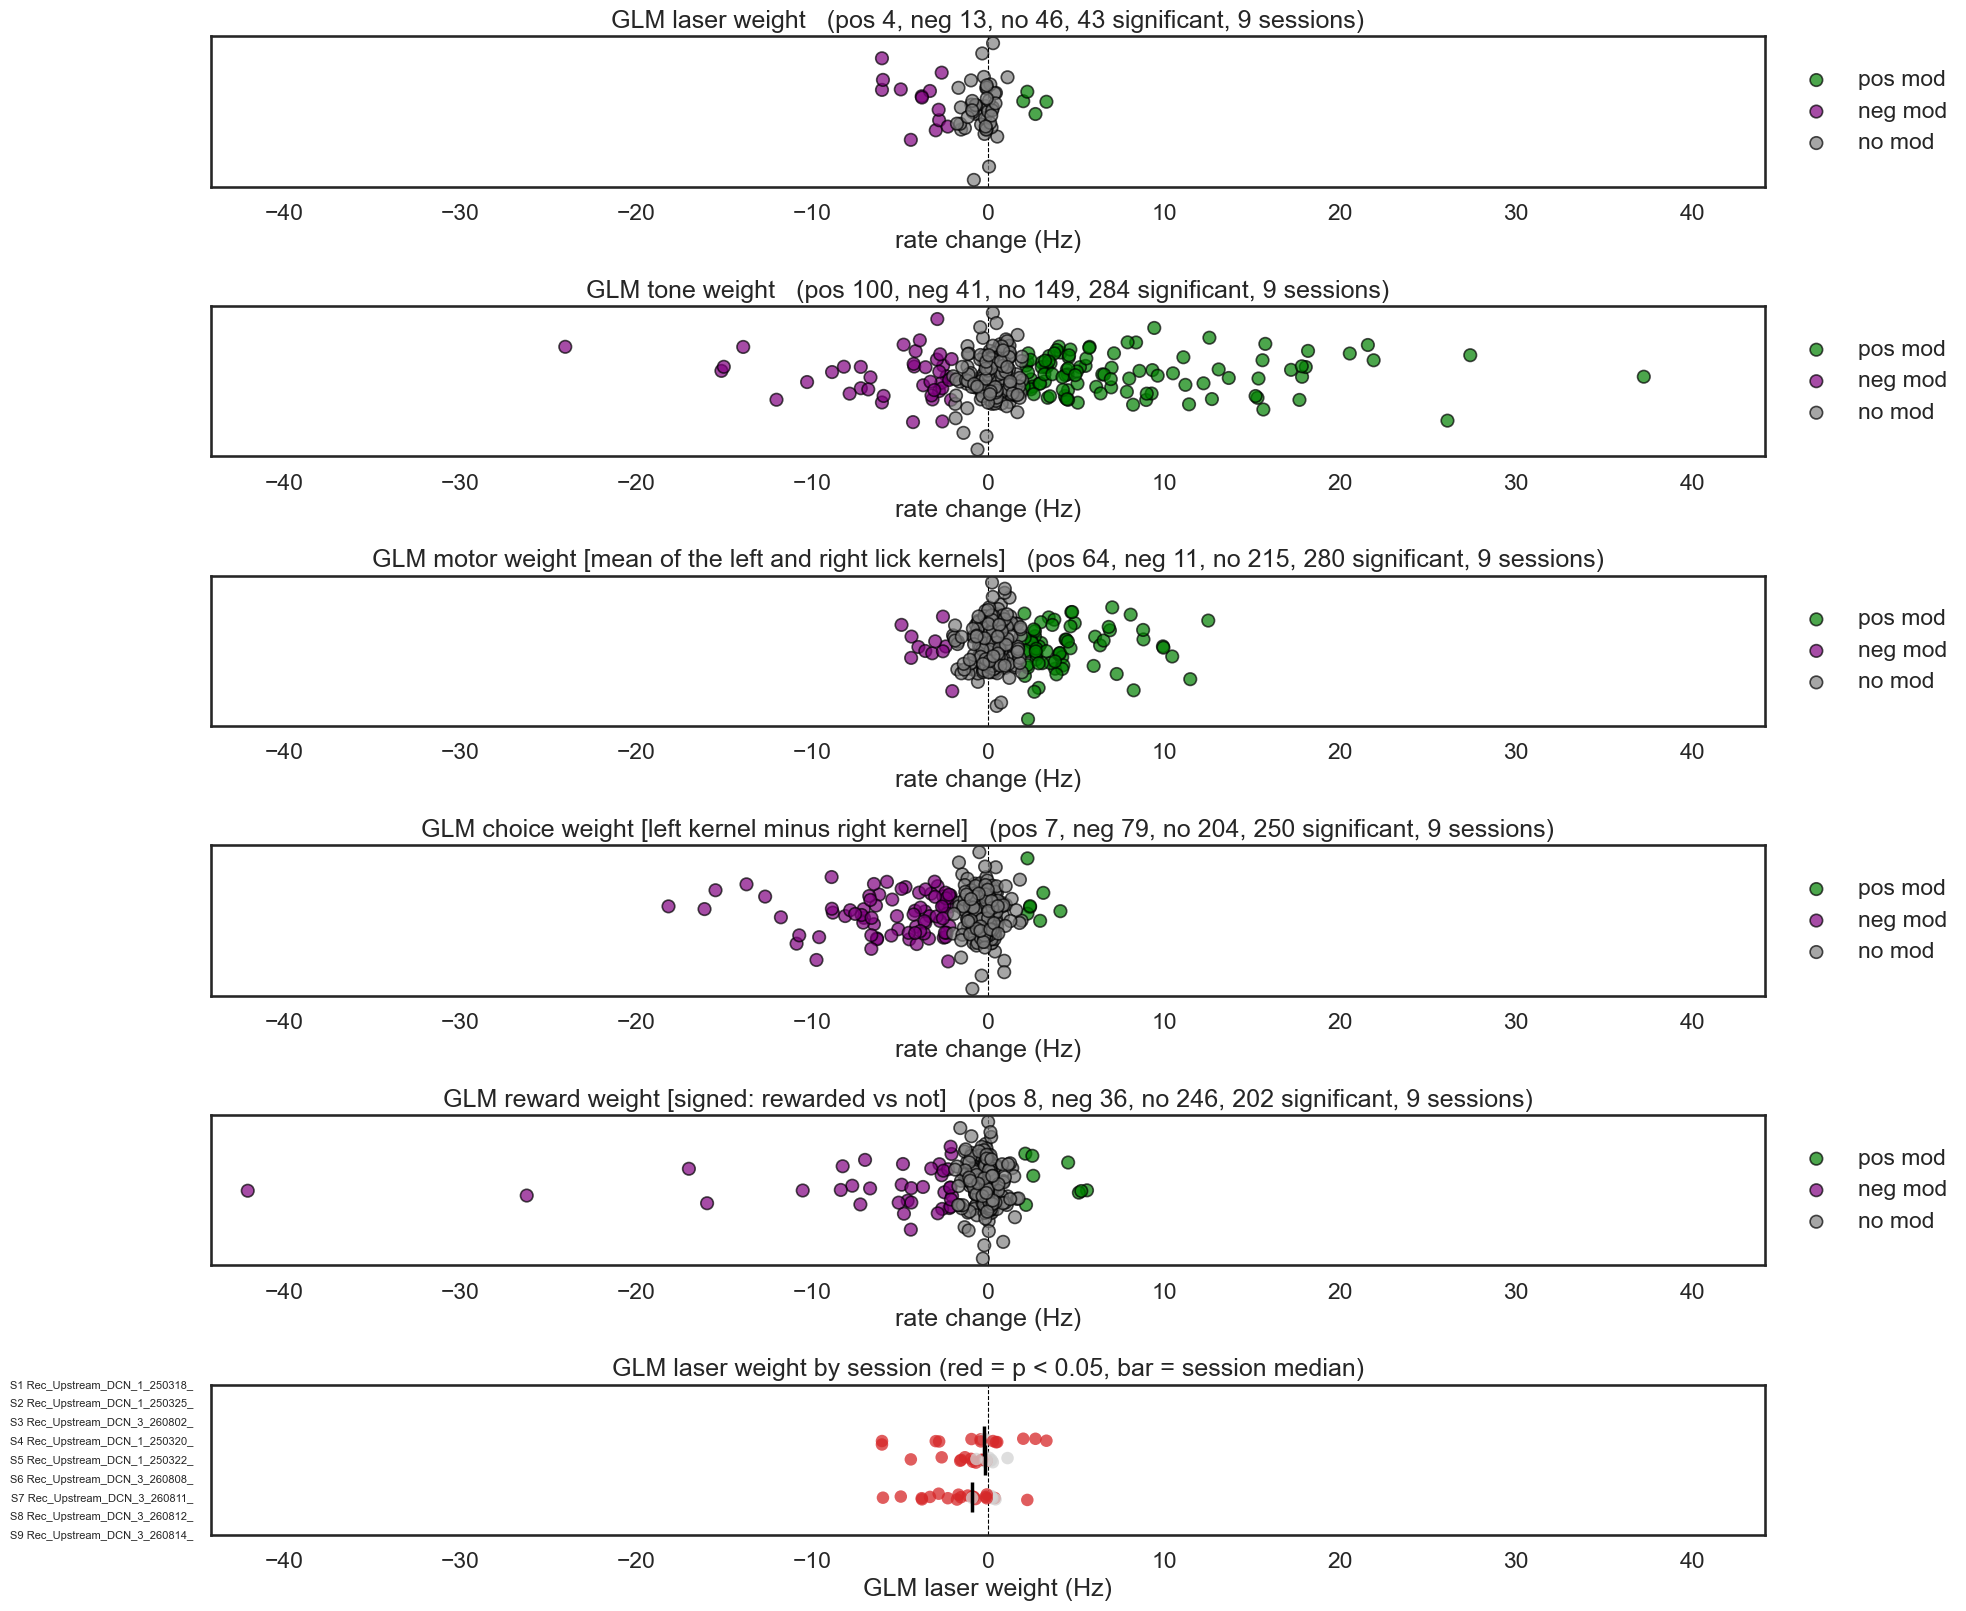

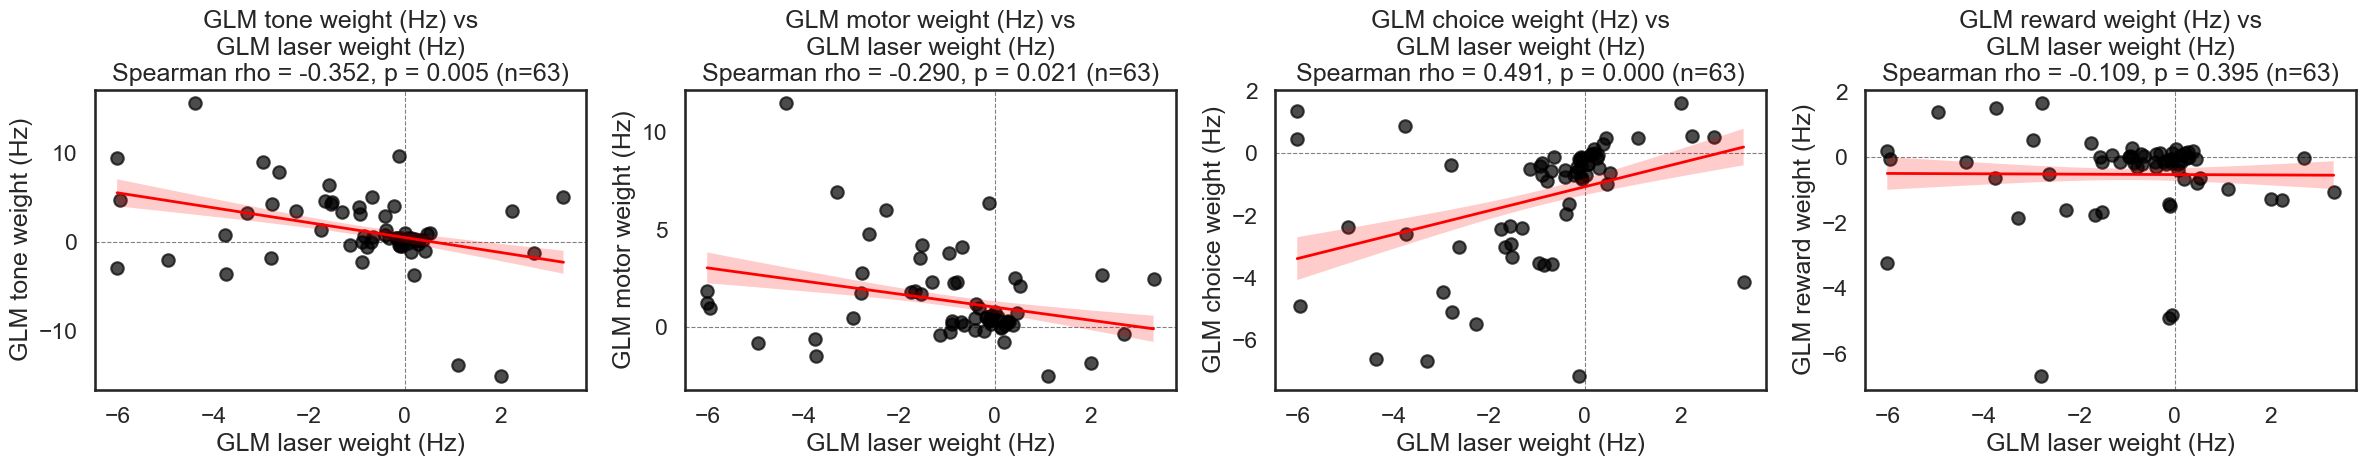

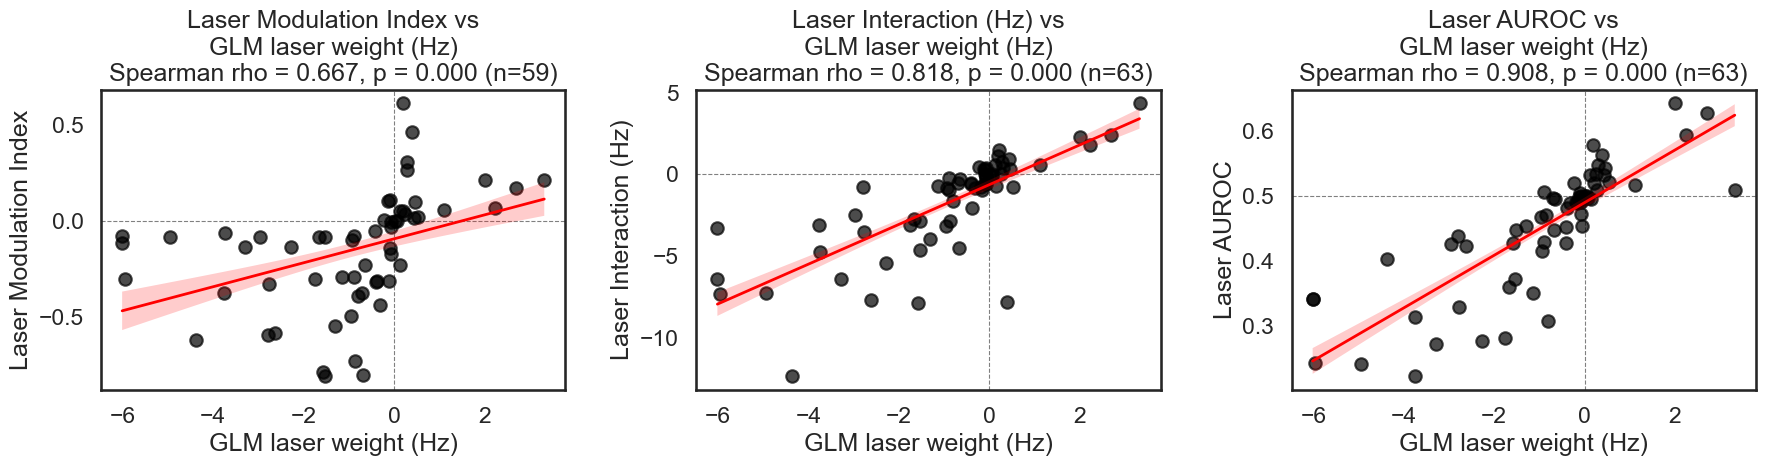

In [10]:
# GLM kernel weights, in the style of the modulation-index figures.
from scipy.stats import spearmanr

glm_effect_th = 2.0      # Hz, for the pos/neg/no colouring

if 'glm_effects' not in dir():
    raise RuntimeError("run the GLM cell above first")

kernel_order = ['laser', 'tone', 'motor', 'choice', 'reward']


def symmetric_limit(values, pad=1.05, fallback=1.0):
    """Symmetric x-limit that survives all-NaN input"""
    finite = np.abs(np.asarray(values, dtype=float))
    finite = finite[np.isfinite(finite)]
    return (max(finite.max(), 1e-9) * pad) if len(finite) else fallback


# ---------- 1. strip plot: one row per kernel, all in Hz, plus a per-session row ----------
fig, axes = plt.subplots(len(kernel_order) + 1, 1,
                         figsize=(20, 2.0 * len(kernel_order) + 0.55 * len(sessions) + 1.5))
axes = np.atleast_1d(axes).flatten()
rng_jitter = np.random.default_rng(0)
jitter = rng_jitter.normal(loc=0, scale=0.1, size=len(units_table))

lim = symmetric_limit(np.concatenate([glm_effects[k] for k in kernel_order]))

for ax, name in zip(axes, kernel_order):
    values = np.asarray(glm_effects[name], dtype=float)
    sig = np.asarray(glm_pvalues[name], dtype=float) < glm_sig_level
    pos = values > glm_effect_th
    neg = values < -glm_effect_th
    none_ = ~pos & ~neg & np.isfinite(values)
    for mask, color, label in [(pos, 'green', 'pos mod'), (neg, 'purple', 'neg mod'),
                               (none_, 'gray', 'no mod')]:
        ax.scatter(values[mask], jitter[mask], color=color, alpha=0.7,
                   edgecolors=np.where(sig[mask], 'black', 'none'), linewidths=1.2, label=label)
    ax.axvline(0, color='k', lw=0.8, ls='--', zorder=0)
    ax.set_xlim(-lim, lim)              # shared scale: all kernels are in Hz
    ax.set_yticks([])
    ax.set_xlabel('rate change (Hz)')
    notes = {'choice': ' [left kernel minus right kernel]',
             'reward': ' [signed: rewarded vs not]',
             'motor': ' [mean of the left and right lick kernels]'}
    ax.set_title(f"GLM {name} weight{notes.get(name, '')}   (pos {int(pos.sum())}, "
                 f"neg {int(neg.sum())}, no {int(none_.sum())}, "
                 f"{int(np.nansum(sig))} significant, {len(sessions)} sessions)")
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.005, 0.5))

# the row that only a multi-session notebook can draw
ax = axes[len(kernel_order)]
laser_w = np.asarray(glm_effects['laser'], dtype=float)
laser_sig = np.asarray(glm_pvalues['laser'], dtype=float) < glm_sig_level
for i, s in enumerate(sessions):
    m = session_of_unit == s['session_id']
    y = np.full(int(m.sum()), i) + rng_jitter.normal(0, 0.08, int(m.sum()))
    ax.scatter(laser_w[m], y, alpha=0.75,
               color=np.where(laser_sig[m], 'tab:red', 'lightgray'),
               edgecolors='none')
    finite = laser_w[m][np.isfinite(laser_w[m])]
    if len(finite):
        ax.plot(np.median(finite), i, marker='|', ms=22, mew=2.5, color='black', zorder=3)
ax.axvline(0, color='k', lw=0.8, ls='--', zorder=0)
ax.set_xlim(-lim, lim)
ax.set_yticks(range(len(sessions)))
ax.set_yticklabels([f"{s['tag']} {s['session_id'][:26]}" for s in sessions], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('GLM laser weight (Hz)')
ax.set_title('GLM laser weight by session (red = p < %.2f, bar = session median)' % glm_sig_level)

plt.tight_layout()
plt.show()


def scatter_with_fit(ax, xs, ys, x_title, y_title, x_centre=0.0, y_centre=0.0):
    """Scatter + least-squares line with SEM band + Spearman correlation"""
    xs, ys = np.asarray(xs, dtype=float), np.asarray(ys, dtype=float)
    ok = np.isfinite(xs) & np.isfinite(ys)
    xs, ys = xs[ok], ys[ok]
    ax.scatter(xs, ys, color='black', alpha=0.7)
    n = len(xs)
    if n > 2 and np.ptp(xs) > 0:
        m, b = np.polyfit(xs, ys, 1)
        x_fit = np.linspace(xs.min(), xs.max(), 100)
        y_fit = m * x_fit + b
        resid = ys - (m * xs + b)
        s_err = np.sqrt(np.sum(resid ** 2) / (n - 2))
        Sxx = np.sum((xs - xs.mean()) ** 2)
        sem = (s_err * np.sqrt(1 / n + (x_fit - xs.mean()) ** 2 / Sxx)
               if Sxx > 0 else np.full_like(x_fit, np.nan))
        ax.plot(x_fit, y_fit, color='red', linewidth=2)
        ax.fill_between(x_fit, y_fit - sem, y_fit + sem, color='red', alpha=0.2, edgecolor='none')
        rho, pval = spearmanr(xs, ys)
        ax.set_title(f"{y_title} vs\n{x_title}\nSpearman rho = {rho:.3f}, p = {pval:.3f} (n={n})")
    else:
        ax.set_title(f"{y_title} vs\n{x_title}\n(too few points)")
    ax.axhline(y_centre, color='gray', lw=0.8, ls='--', zorder=0)
    ax.axvline(x_centre, color='gray', lw=0.8, ls='--', zorder=0)
    ax.set_xlabel(x_title)
    ax.set_ylabel(y_title)


# ---------- 2. laser weight vs every other kernel weight, all from the same fit ----------
others = [k for k in kernel_order if k != 'laser']
fig, axes = plt.subplots(1, len(others), figsize=(6 * len(others), 5))
for ax, name in zip(np.atleast_1d(axes), others):
    scatter_with_fit(ax, glm_effects['laser'], glm_effects[name],
                     "GLM laser weight (Hz)", f"GLM {name} weight (Hz)")
plt.tight_layout()
plt.show()

# ---------- 3. how far the GLM agrees with the window-based laser measures ----------
window_measures = [("Laser Modulation Index", laser_mod_index, True, 0.0),
                   ("Laser Interaction (Hz)", laser_interaction_hz, False, 0.0),
                   ("Laser AUROC", laser_auroc, False, 0.5)]
fig, axes = plt.subplots(1, len(window_measures), figsize=(6 * len(window_measures), 5))
for ax, (y_title, y_index, drop_saturated, y_centre) in zip(np.atleast_1d(axes), window_measures):
    y_index = np.asarray(y_index, dtype=float)
    keep = (~np.isclose(np.abs(y_index), 1.0, atol=1e-8) if drop_saturated
            else np.ones(len(y_index), bool))
    scatter_with_fit(ax, glm_effects['laser'][keep], y_index[keep],
                     "GLM laser weight (Hz)", y_title, y_centre=y_centre)
plt.tight_layout()
plt.show()

### 2.4. Plot modulation index

**What each metric below measures.** All windows are set at the top of the
modulation-index cell; the laser window is derived from the session itself.

**Ratio indices** (`get_mod_index(..., type='norm')`) — mean rate over trials and bins
in window **A** vs window **B**:

$$\text{index} = \frac{\bar{A} - \bar{B}}{\bar{A} + \bar{B}} \in [-1, 1]$$

| metric | aligned to | A | B | trials used |
|---|---|---|---|---|
| Tone | trial start | 0–50 ms | −75 to −25 ms | control only |
| Choice | choice lick | 0–75 ms, **left** | 0–75 ms, **right** | control only |
| Motor | last lick | 0–100 ms | 150–250 ms | control only |
| Reward | second lick | 0–200 ms, **rewarded** | 0–200 ms, **non-rewarded** | control only |
| Laser | trial start | laser window, **laser** trials | same window, **control** trials | both |

Note the two different kinds of contrast. Tone and Motor compare a response window
against a reference window *within the same trials*, so positive means "above its own
baseline". Choice, Reward and Laser compare *two conditions in the same window*, so a
positive Laser index means **more than control**, not more than baseline — a unit that
is suppressed by the task but less suppressed on laser trials still scores positive.

Because it is a ratio, it pins at ±1 whenever one side is near zero. That is a sparse
unit, not a strong effect, which is why the scatter cell drops saturated points.

**Laser Interaction (Hz)** — the same laser contrast expressed as a difference of
differences against a −500 to 0 ms baseline:

$$(\bar{A}_{laser} - \bar{B}_{laser}) - (\bar{A}_{control} - \bar{B}_{control})$$

This removes any pre-existing difference between laser and control trials and reports
the effect in Hz, so a +14 Hz change on an active unit no longer scores below a +1 Hz
change on a near-silent one.

**Laser AUROC** — the probability that a randomly chosen laser trial has a higher rate
than a randomly chosen control trial (ties count a half), from per-trial mean rates in
the laser window. 0.5 means the conditions are indistinguishable. Being rank-based it
cannot saturate, but ties pull it toward 0.5 for sparse units.

**Colour coding** is descriptive, not a statistical test — each row uses its own centre
and threshold (`th` for the ratio rows, `interaction_th` in Hz, `auroc_th` around 0.5).
For significance, use the p-values printed by the modulation-index cell or the GLM.

*Caveat on the Reward index:* `RMI` takes three values in these sessions — `reward`,
`mistrial` and `incorrect` — and the trial conditions treat everything that is not
`reward` as non-rewarded, so "non-rewarded" pools error trials with non-responses.

**Across sessions.** Each unit keeps the index computed inside its own session, with
that session's own laser window; the vectors below are those per-unit values
concatenated. Sessions without laser trials contribute NaN to the laser rows and drop
out of them silently.

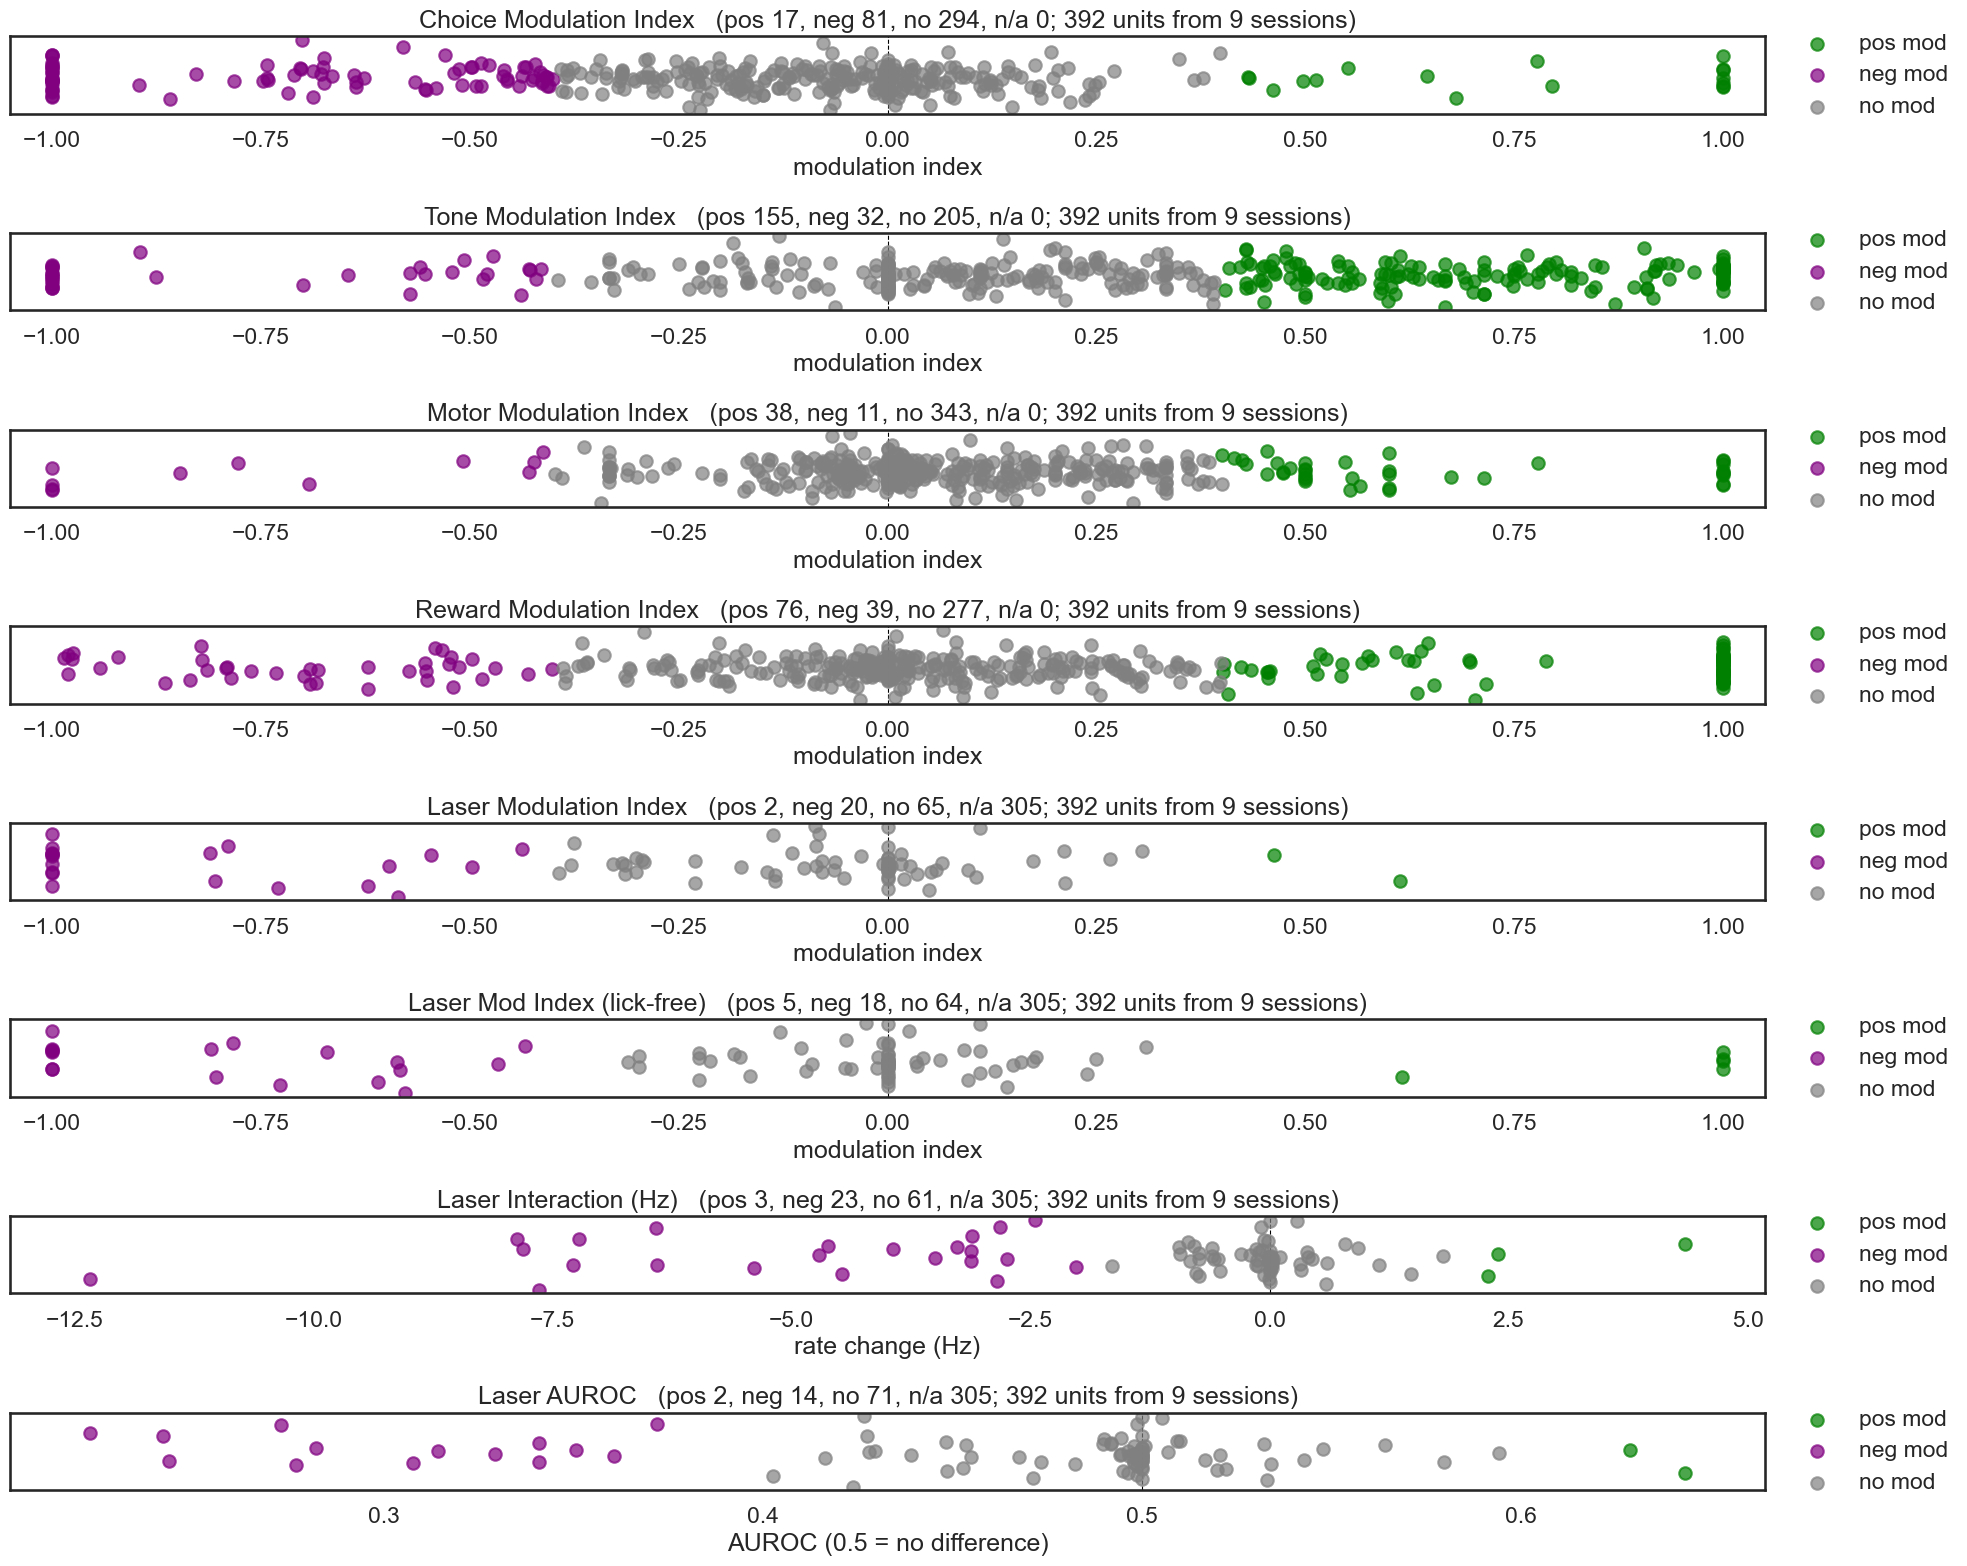

In [11]:
# Plot and group all modulation indices, one row each, pooled over sessions.
# The ratio indices are bounded [-1, 1] and centred on 0; the laser interaction is in
# Hz (unbounded) and AUROC is centred on 0.5, so each row carries its own centre,
# threshold and x-axis rather than sharing one.
th = 0.4                 # ratio-index threshold
interaction_th = 2.0     # Hz, for the interaction row
auroc_th = 0.1           # distance from 0.5, for the AUROC row

mod_indices = [
    # (title, values, centre, threshold, xlabel)
    ("Choice Modulation Index",      choice_mod_index,             0.0, th,             'modulation index'),
    ("Tone Modulation Index",        tone_mod_index,               0.0, th,             'modulation index'),
    ("Motor Modulation Index",       motor_mod_index,              0.0, th,             'modulation index'),
    ("Reward Modulation Index",      reward_mod_index,             0.0, th,             'modulation index'),
    ("Laser Modulation Index",       laser_mod_index,              0.0, th,             'modulation index'),
    ("Laser Mod Index (lick-free)",  mod['laser_index_lickfree'],  0.0, th,             'modulation index'),
    ("Laser Interaction (Hz)",       laser_interaction_hz,         0.0, interaction_th, 'rate change (Hz)'),
    ("Laser AUROC",                  laser_auroc,                  0.5, auroc_th,       'AUROC (0.5 = no difference)'),
]

fig, axes = plt.subplots(len(mod_indices), 1, figsize=(20, 2 * len(mod_indices)))
axes_flat = np.atleast_1d(axes).flatten()

y_jitter = np.random.default_rng(1).normal(loc=0, scale=0.1, size=len(units_table))

pos_mod_color = 'green'
neg_mod_color = 'purple'
no_mod_color = 'gray'

# the bounded ratio rows keep a common x-range so they stay comparable
ratio_values = np.concatenate([np.asarray(v, dtype=float) for _, v, c, _, _ in mod_indices
                               if c == 0.0 and np.nanmax(np.abs(v)) <= 1.0])
ratio_xlim = (np.nanmin(ratio_values) - 0.05, np.nanmax(ratio_values) + 0.05)

for ax, (title, mod_index, centre, threshold, xlabel) in zip(axes_flat, mod_indices):
    mod_index = np.asarray(mod_index, dtype=float)
    pos_mask = mod_index > centre + threshold
    neg_mask = mod_index < centre - threshold
    no_mask = ~pos_mask & ~neg_mask & np.isfinite(mod_index)
    ax.scatter(mod_index[pos_mask], y_jitter[pos_mask], color=pos_mod_color, alpha=0.7, label='pos mod')
    ax.scatter(mod_index[neg_mask], y_jitter[neg_mask], color=neg_mod_color, alpha=0.7, label='neg mod')
    ax.scatter(mod_index[no_mask],  y_jitter[no_mask],  color=no_mod_color,  alpha=0.7, label='no mod')
    ax.axvline(centre, color='k', lw=0.8, ls='--', zorder=0)
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_xlabel(xlabel)
    n_missing = int((~np.isfinite(mod_index)).sum())
    ax.set_title(f"{title}   (pos {int(pos_mask.sum())}, neg {int(neg_mask.sum())}, "
                 f"no {int(no_mask.sum())}, n/a {n_missing}; "
                 f"{len(units_table)} units from {len(sessions)} sessions)")
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.005, 0.5))
    if centre == 0.0 and np.nanmax(np.abs(mod_index)) <= 1.0:
        ax.set_xlim(*ratio_xlim)

plt.tight_layout()
plt.show()

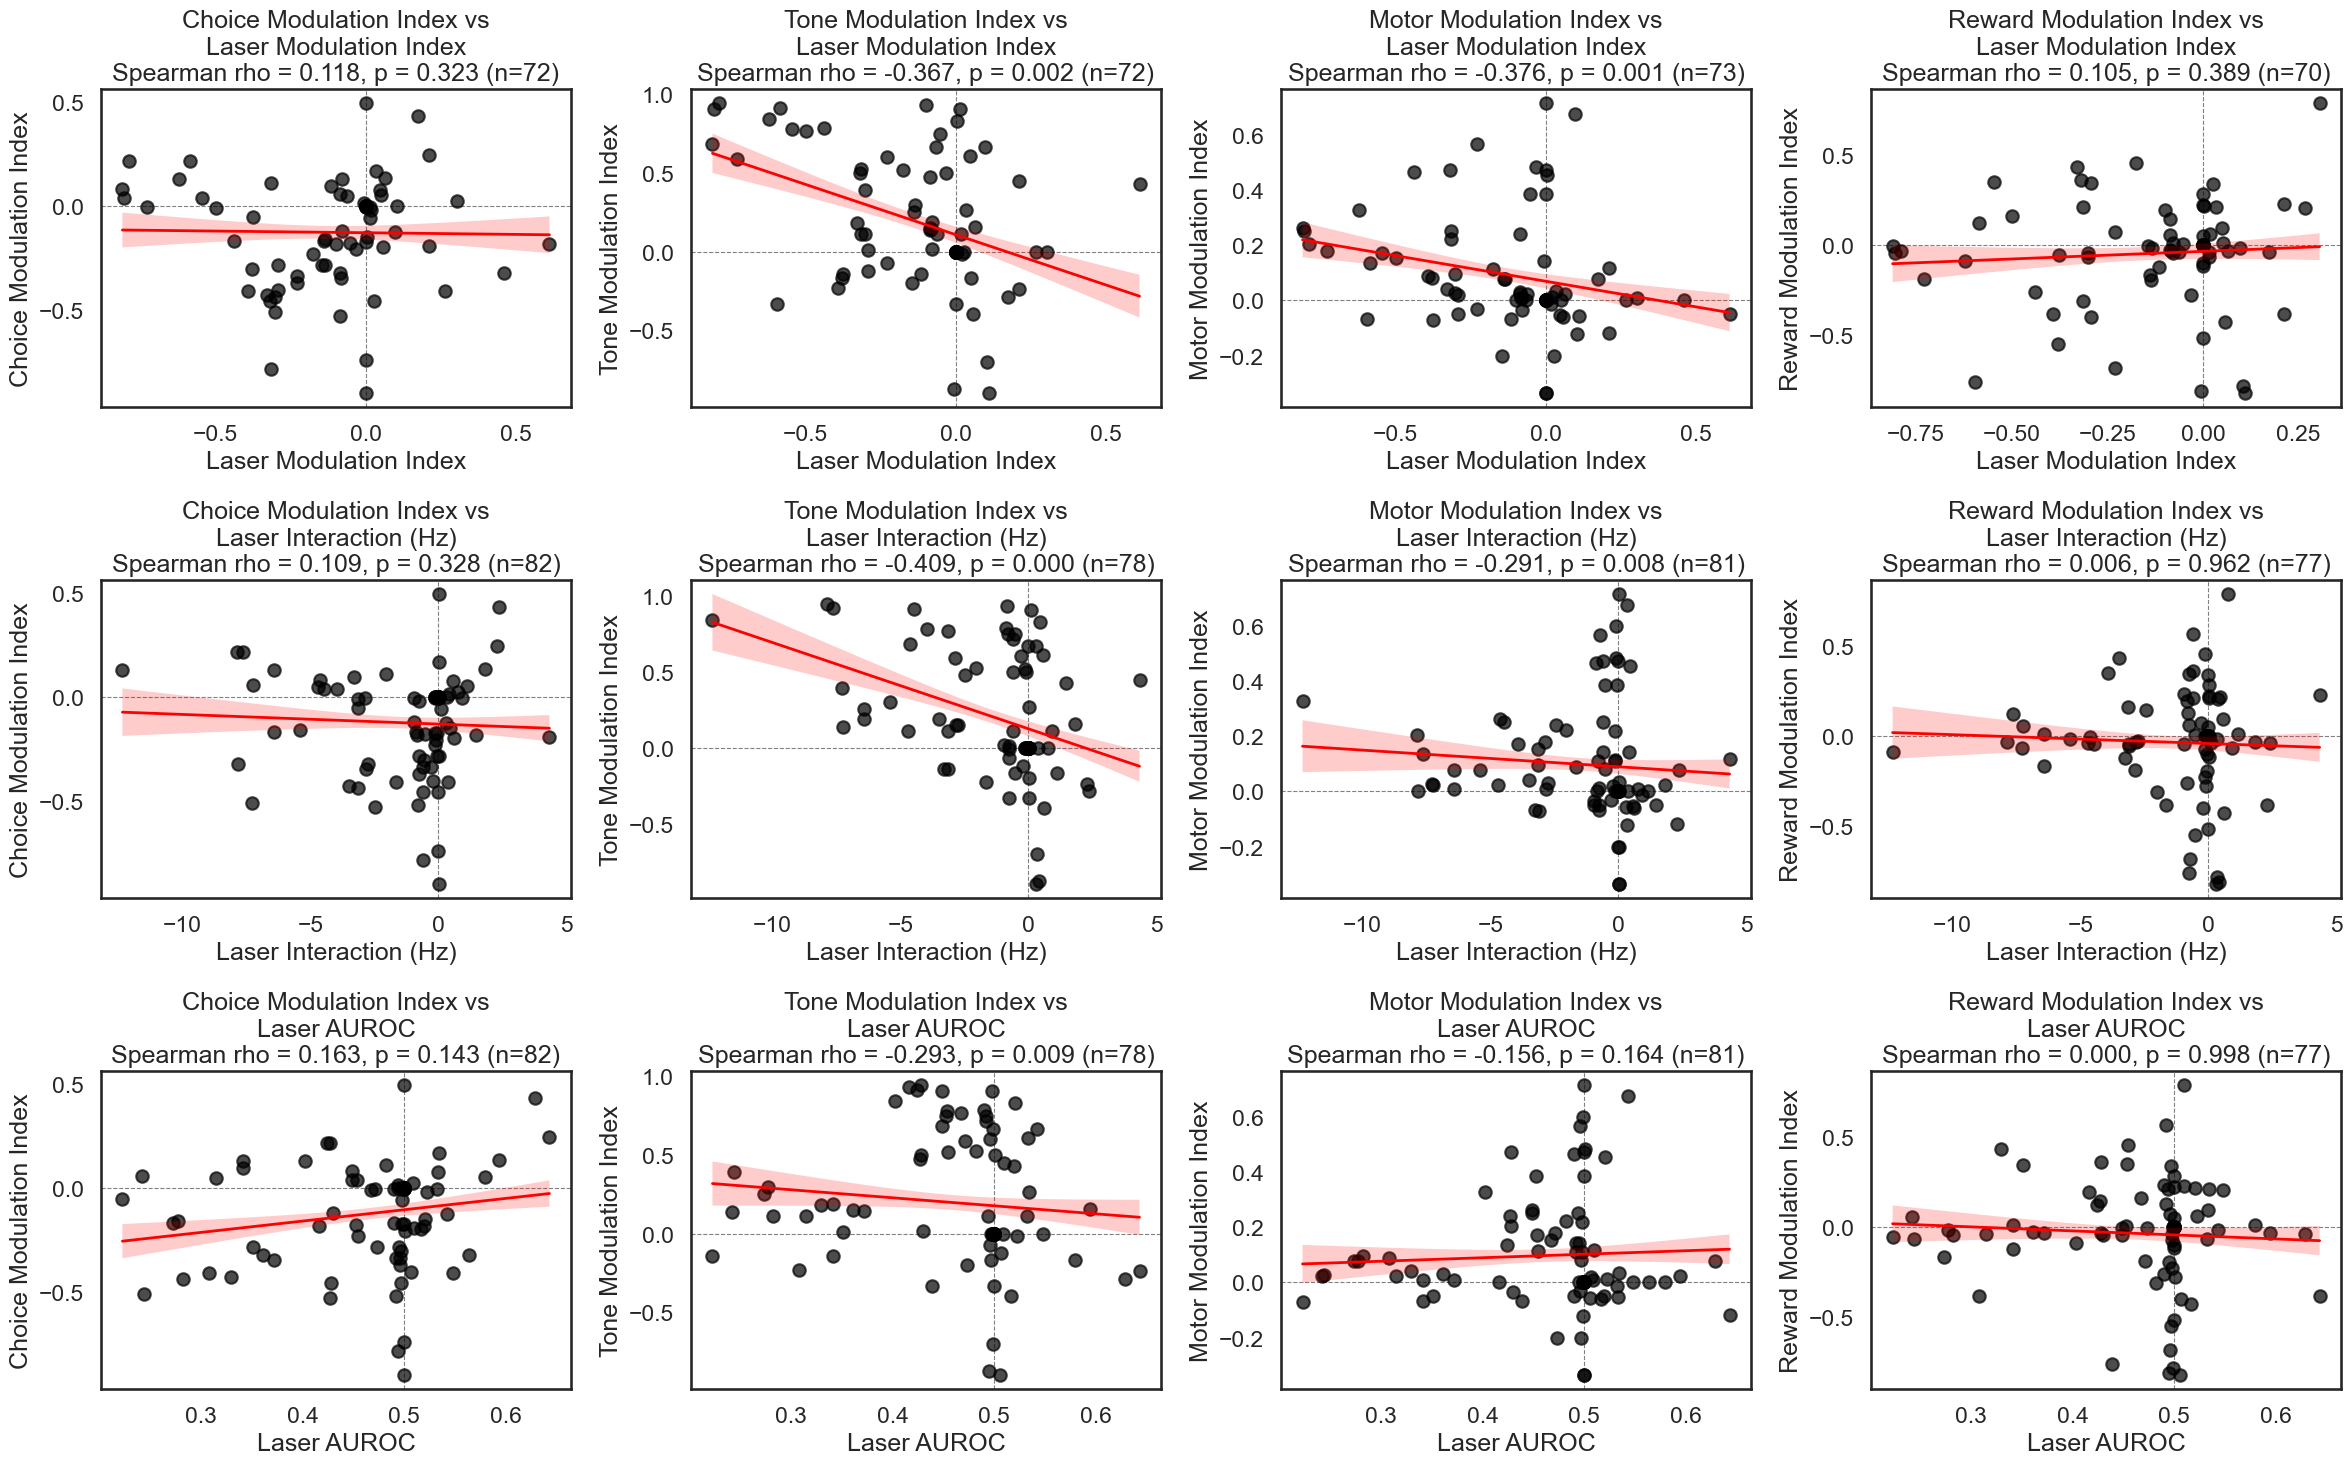

Spearman rho, pooled vs per session:
  Laser Modulation Index   x Choice Modulation Index  pooled +0.044 (p=0.686, n=87)  |  S4 +0.38, S5 -0.22, S7 +0.35
  Laser Modulation Index   x Tone Modulation Index    pooled -0.337 (p=0.001, n=87)  |  S4 -0.08, S5 -0.68, S7 +0.04
  Laser Modulation Index   x Motor Modulation Index   pooled -0.277 (p=0.009, n=87)  |  S4 +0.10, S5 -0.10, S7 -0.39
  Laser Modulation Index   x Reward Modulation Index  pooled +0.052 (p=0.634, n=87)  |  S4 -0.16, S5 +0.08, S7 +0.05
  Laser Interaction (Hz)   x Choice Modulation Index  pooled +0.059 (p=0.590, n=87)  |  S4 +0.20, S5 -0.42, S7 +0.50
  Laser Interaction (Hz)   x Tone Modulation Index    pooled -0.403 (p=0.000, n=87)  |  S4 -0.12, S5 -0.66, S7 -0.32
  Laser Interaction (Hz)   x Motor Modulation Index   pooled -0.224 (p=0.037, n=87)  |  S4 +0.13, S5 -0.31, S7 -0.25
  Laser Interaction (Hz)   x Reward Modulation Index  pooled +0.083 (p=0.444, n=87)  |  S4 -0.17, S5 +0.24, S7 +0.07
  Laser AUROC              

In [12]:
# Scatter grid: each laser measure (rows) against the other indices (columns),
# with a best-fit line, its SEM band, and the Spearman correlation. All units pooled.
from scipy.stats import spearmanr

y_indices = [
    ("Choice Modulation Index", choice_mod_index),
    ("Tone Modulation Index", tone_mod_index),
    ("Motor Modulation Index", motor_mod_index),
    ("Reward Modulation Index", reward_mod_index),
]

# rows: the three ways of scoring the laser effect
x_measures = [
    ("Laser Modulation Index", laser_mod_index, True),    # bounded ratio -> drop saturated units
    ("Laser Interaction (Hz)", laser_interaction_hz, False),
    ("Laser AUROC", laser_auroc, False),
]

fig, axes = plt.subplots(len(x_measures), len(y_indices),
                         figsize=(6 * len(y_indices), 5 * len(x_measures)))
axes = np.atleast_2d(axes)
tol = 1e-8

for row, (x_title, x_index, drop_saturated_x) in enumerate(x_measures):
    x_index = np.asarray(x_index, dtype=float)
    for col, (y_title, y_index) in enumerate(y_indices):
        ax = axes[row, col]
        y_index = np.asarray(y_index, dtype=float)

        # A ratio index pinned at +-1 means one side of the ratio was ~0, not a real
        # extreme, so drop those. Interaction and AUROC have no such saturation.
        mask = np.isfinite(x_index) & np.isfinite(y_index)
        mask &= ~np.isclose(np.abs(y_index), 1.0, atol=tol)
        if drop_saturated_x:
            mask &= ~np.isclose(np.abs(x_index), 1.0, atol=tol)
        xs, ys = x_index[mask], y_index[mask]

        ax.scatter(xs, ys, color='black', alpha=0.7)

        n = len(xs)
        if n > 2 and np.ptp(xs) > 0:
            m, b = np.polyfit(xs, ys, 1)
            x_fit = np.linspace(xs.min(), xs.max(), 100)
            y_fit = m * x_fit + b
            residuals = ys - (m * xs + b)
            s_err = np.sqrt(np.sum(residuals ** 2) / (n - 2))
            x_mean = xs.mean()
            Sxx = np.sum((xs - x_mean) ** 2)
            sem_fit = (s_err * np.sqrt(1 / n + (x_fit - x_mean) ** 2 / Sxx)
                       if Sxx > 0 else np.full_like(x_fit, np.nan))
            ax.plot(x_fit, y_fit, color='red', linewidth=2)
            ax.fill_between(x_fit, y_fit - sem_fit, y_fit + sem_fit,
                            color='red', alpha=0.2, edgecolor='none')
            rho, pval = spearmanr(xs, ys)
            ax.set_title(f"{y_title} vs\n{x_title}\nSpearman rho = {rho:.3f}, p = {pval:.3f} (n={n})")
        else:
            ax.set_title(f"{y_title} vs\n{x_title}\n(too few points)")

        ax.axhline(0, color='gray', lw=0.8, ls='--', zorder=0)
        ax.axvline(0.5 if 'AUROC' in x_title else 0.0, color='gray', lw=0.8, ls='--', zorder=0)
        ax.set_xlabel(x_title)
        ax.set_ylabel(y_title)

plt.tight_layout()
plt.show()

# Pooling units from several sessions can create a correlation that exists in none of
# them (Simpson's paradox), so the same rho is printed per session for comparison.
print(f"Spearman rho, pooled vs per session:")
for x_title, x_index, _ in x_measures:
    x_index = np.asarray(x_index, dtype=float)
    for y_title, y_index in y_indices:
        y_index = np.asarray(y_index, dtype=float)
        ok = np.isfinite(x_index) & np.isfinite(y_index)
        if ok.sum() < 3:
            continue
        rho_all, p_all = spearmanr(x_index[ok], y_index[ok])
        per = []
        for s in sessions:
            m = ok & (session_of_unit == s['session_id'])
            if m.sum() >= 5:
                r, _ = spearmanr(x_index[m], y_index[m])
                per.append(f"{s['tag']} {r:+.2f}")
        print(f"  {x_title:24s} x {y_title:24s} pooled {rho_all:+.3f} (p={p_all:.3f}, "
              f"n={int(ok.sum())})  |  " + ", ".join(per))

  ! reward_left_laser: no trials in this session
  ! reward_right_laser: no trials in this session


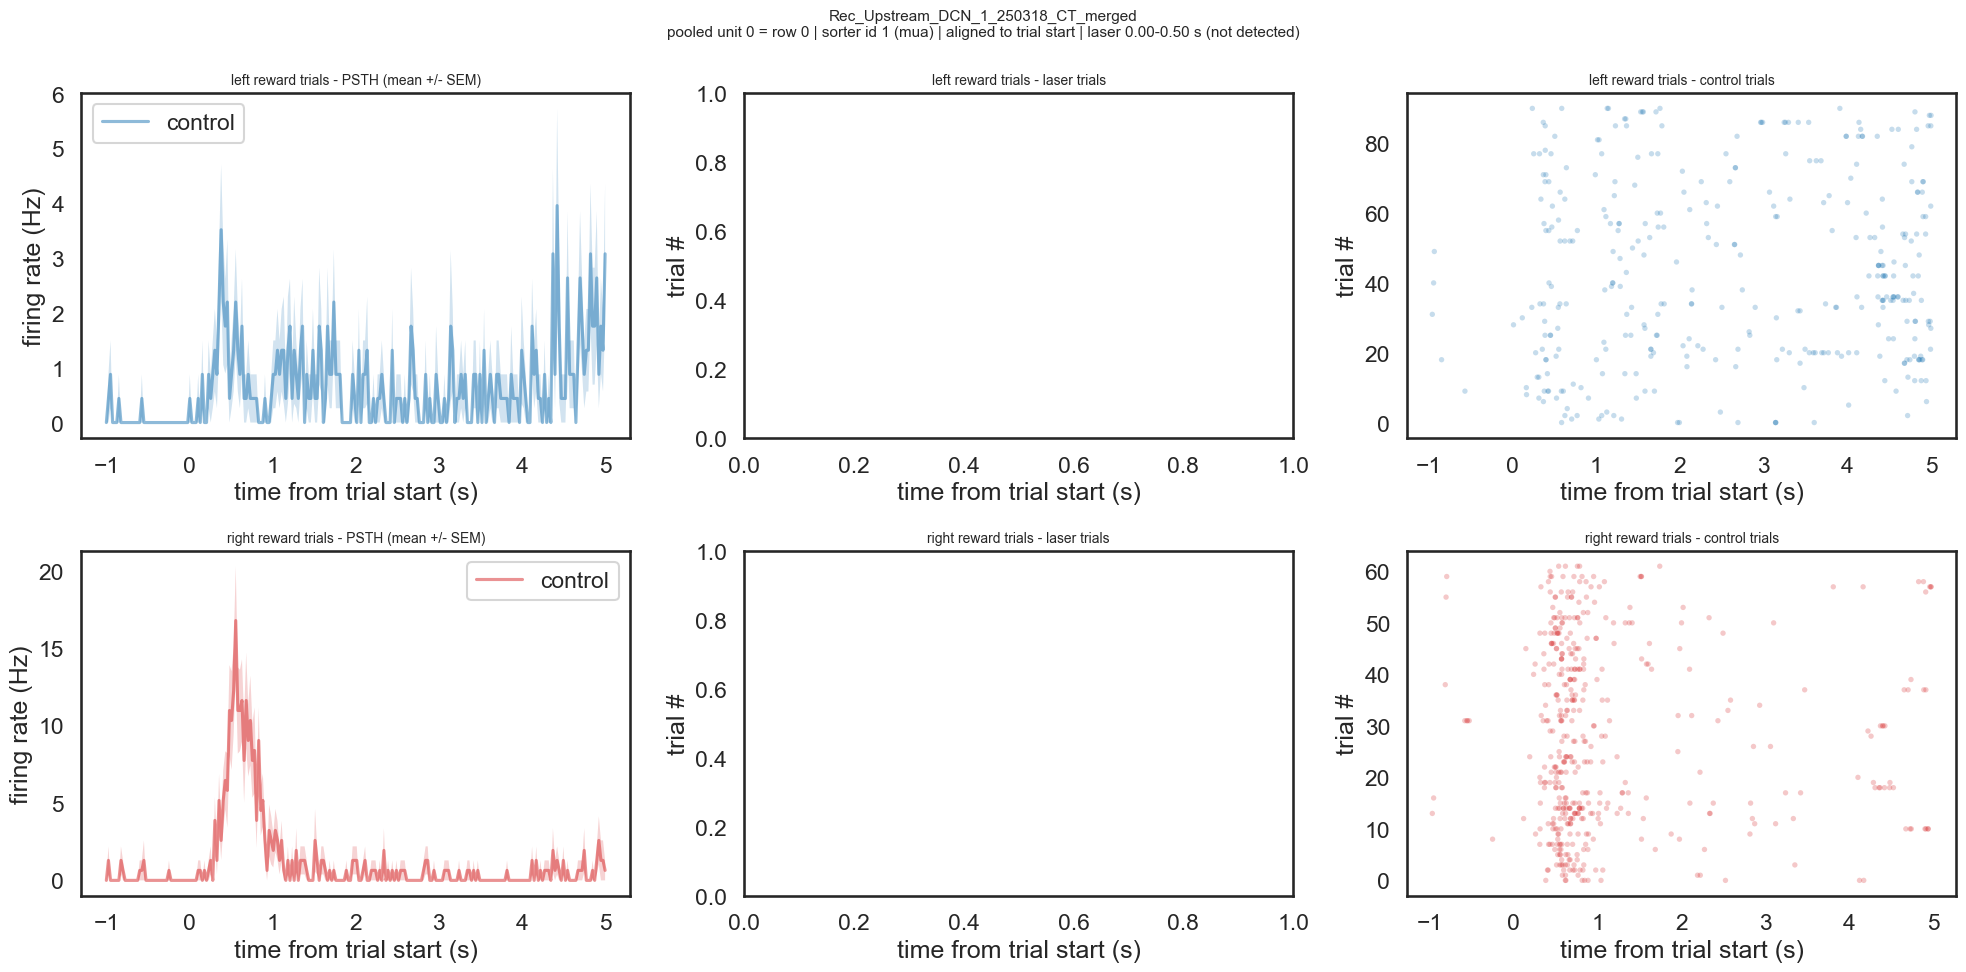

Tone modulation index: +1.0000
Choice modulation index: -0.2360
Motor modulation index: +0.2273
Reward modulation index: +0.3987
Laser modulation index: +nan
Laser interaction: +nan Hz
Laser AUROC: nan (p = nan)
GLM laser weight: +nan Hz (p = nan)


In [13]:
# One unit's PSTH and rasters. `pooled_unit` indexes units_table, i.e. the same index
# used by every point in the pooled figures above.
pooled_unit = 0

row = units_table.iloc[pooled_unit]
sess = next(s for s in sessions if s['session_id'] == row['session_id'])
unit_id = int(row['row'])
aligned, xa = sess['aligned_trial_start'], sess['xaxis']
laser_onset, laser_duration = sess['laser_onset'], sess['laser_duration']

left_color   = 'tab:blue'
right_color  = 'tab:red'
laser_color  = 'tab:cyan'
alpha_ctrl   = 0.5
alpha_laser  = 1.0

fig, ax = plt.subplots(2, 3, figsize=(20, 10))


def n_trials_in(cond):
    return aligned[cond]['rate'].shape[1] if cond in aligned else 0


for r, (side, color) in enumerate([('left', left_color), ('right', right_color)]):
    for cond, alpha, raster_col in [(f'reward_{side}_laser', alpha_laser, 1),
                                    (f'reward_{side}_control', alpha_ctrl, 2)]:
        if not n_trials_in(cond):
            print(f"  ! {cond}: no trials in this session")
            continue
        label = 'laser' if 'laser' in cond else 'control'
        ndap.plot_sem(aligned[cond]['rate'][unit_id, :, :], x=xa, color=color, alpha=alpha,
                      plot_individual=False, ax=ax[r, 0], label=label)
        ndap.plot_raster(aligned[cond]['times'][unit_id], x=xa, color=color,
                         alpha=0.5 * alpha, ax=ax[r, raster_col])
    ax[r, 0].legend()

# ----- label the axes and mark the laser -----
# Everything here is aligned to TRIAL START (event_times['trial_start_times'],
# i.e. the TimeStart column of the trial table). t = 0 is trial start.
col_titles = ['PSTH (mean +/- SEM)', 'laser trials', 'control trials']
row_titles = ['left reward trials', 'right reward trials']
for r in range(2):
    for c in range(3):
        ax[r, c].set_xlabel('time from trial start (s)')
        ax[r, c].set_ylabel('firing rate (Hz)' if c == 0 else 'trial #')
        ax[r, c].set_title(f'{row_titles[r]} - {col_titles[c]}', fontsize=10)
        # laser on only in the PSTH and the laser-trial raster
        if c in (0, 1) and sess['has_laser']:
            ax[r, c].axvspan(laser_onset, laser_onset + laser_duration,
                             facecolor=laser_color, alpha=0.15, zorder=0, edgecolor='none',
                             label='laser on' if (r == 0 and c == 1) else None)

fig.suptitle(f"{sess['session_id']}\npooled unit {pooled_unit} = row {unit_id} "
             f"| sorter id {row['unit_id']} ({row['label']}) | aligned to trial start | "
             f"laser {laser_onset:.2f}-{laser_onset + laser_duration:.2f} s "
             f"({sess['laser_source']})", fontsize=11)
fig.tight_layout()
plt.show()

for name, values in [('Tone', tone_mod_index), ('Choice', choice_mod_index),
                     ('Motor', motor_mod_index), ('Reward', reward_mod_index),
                     ('Laser', laser_mod_index)]:
    print(f"{name} modulation index: {values[pooled_unit]:+.4f}")
print(f"Laser interaction: {laser_interaction_hz[pooled_unit]:+.3f} Hz")
print(f"Laser AUROC: {laser_auroc[pooled_unit]:.4f} (p = {laser_pvalue[pooled_unit]:.4f})")
print(f"GLM laser weight: {glm_effects['laser'][pooled_unit]:+.3f} Hz "
      f"(p = {glm_pvalues['laser'][pooled_unit]:.4f})")

## 3. Plot trajectory aligned to events

These are population quantities, so they are computed **inside** each session and only
the summaries are combined. A projection's scale is set by that session's firing rates
and unit count, so it is z-scored per session before averaging: the shape is comparable,
the amplitude is not.

In [14]:
# shared colours and the per-session rate blocks used by sections 3-5
left_color, right_color, laser_color = 'tab:blue', 'tab:red', 'tab:cyan'
alpha_ctrl, alpha_laser = 0.3, 1.0

CONDITIONS = [f'{outcome}_{side}_{block}'
              for outcome in ('reward', 'nonreward')
              for side in ('left', 'right')
              for block in ('control', 'laser')]

criteria = None      # optional boolean/index array over units, applied within each session


def matching_conditions(sess, keys, aligned_key='aligned_trial_start'):
    """
    Condition names containing every term in `keys`, the same substring rule
    ndap.combine_rates uses.

    Note this is a substring match, so ['reward', 'control'] also matches the
    'nonreward_*_control' conditions - see the caveat under the Reward index.
    """
    keys = [keys] if isinstance(keys, str) else list(keys)
    return [c for c in sess[aligned_key] if all(term in c for term in keys)]


def condition_rates(sess, keys, aligned_key='aligned_trial_start'):
    """
    (units, trials, bins) rates for the conditions matching `keys`, as numpy.

    A control session has no laser conditions at all - not even empty ones - and
    combine_rates raises on an unmatched key, so that case returns a zero-trial
    array and every caller treats it as "this session cannot contribute here".
    """
    if not matching_conditions(sess, keys, aligned_key):
        return np.empty((sess['n_units'] if criteria is None else int(np.sum(criteria)),
                         0, len(sess['xaxis'])))
    rates = ndap.convert_dask_to_numpy(ndap.combine_rates(sess[aligned_key], key=keys))
    return rates[criteria, :, :] if criteria is not None else rates


def n_trials_in(sess, cond, aligned_key='aligned_trial_start'):
    aligned = sess[aligned_key]
    return aligned[cond]['rate'].shape[1] if cond in aligned else 0


def zscore_curves(curves):
    """
    z-score a session's set of curves by their common mean and SD.

    One scale for all conditions in that session, so the differences *between*
    conditions survive; only the arbitrary session-level units are removed.
    """
    stacked = np.concatenate([np.asarray(v, dtype=float).ravel() for v in curves.values()])
    finite = stacked[np.isfinite(stacked)]
    if len(finite) < 2:
        return {k: np.full(np.shape(v), np.nan) for k, v in curves.items()}
    mu, sd = finite.mean(), finite.std()
    if sd == 0:
        return {k: np.full_like(np.asarray(v, dtype=float), np.nan) for k, v in curves.items()}
    return {k: (np.asarray(v, dtype=float) - mu) / sd for k, v in curves.items()}


def pooled_sem_plot(ax, per_session_curves, cond, x, color, alpha, label):
    """mean +/- SEM across sessions for one condition, with the sessions faint behind"""
    stack = np.vstack([per_session_curves[s['session_id']][cond] for s in sessions])
    keep = np.isfinite(stack).any(axis=1)
    if not keep.any():
        return 0
    stack = stack[keep]
    for trace in stack:
        ax.plot(x, trace, color=color, alpha=0.18 * alpha, lw=0.8, zorder=1)
    ndap.plot_sem(stack, x=x, color=color, alpha=alpha, ax=ax,
                  label=f'{label} (n={len(stack)})')
    return len(stack)

### 3.1. Plot projection onto CD_choice

CD projection:   0%|          | 0/9 [00:00<?, ?it/s]

Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']


CD projection:  11%|█         | 1/9 [00:00<00:05,  1.34it/s]

Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']


CD projection:  22%|██▏       | 2/9 [00:02<00:10,  1.54s/it]

...

CD projection:  78%|███████▊  | 7/9 [00:10<00:04,  2.21s/it]

Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']


CD projection:  89%|████████▉ | 8/9 [00:11<00:01,  1.74s/it]

Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']


CD projection: 100%|██████████| 9/9 [00:14<00:00,  1.63s/it]


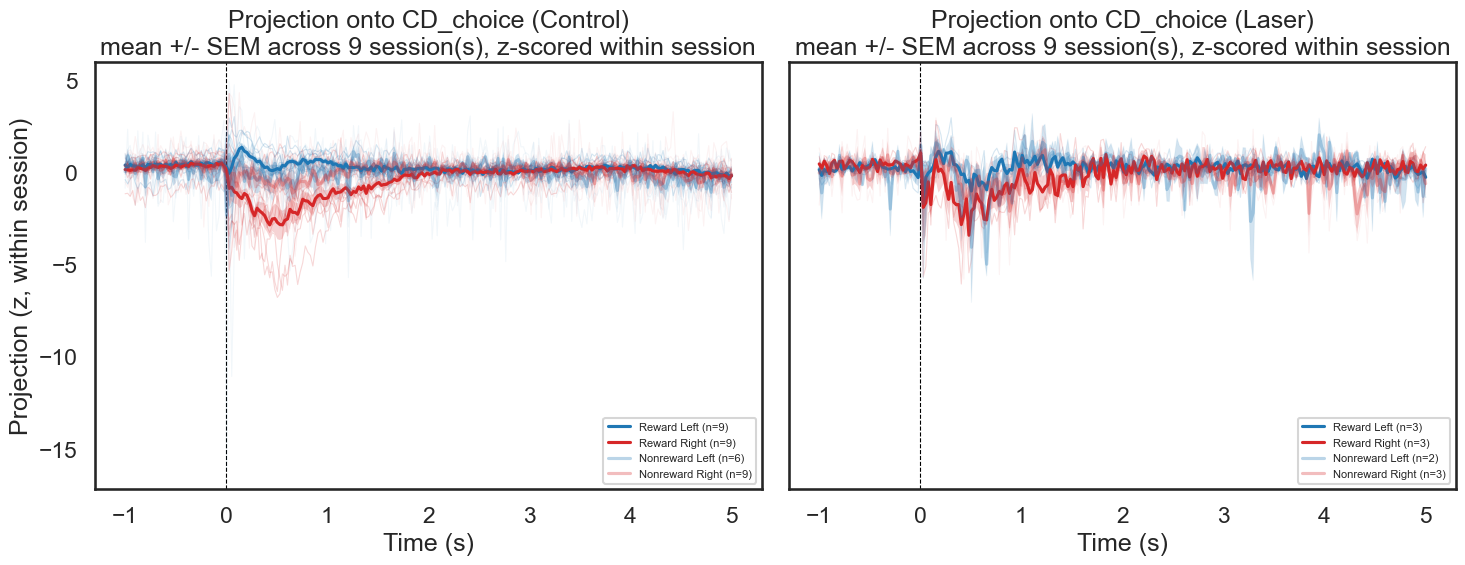

CD_choice per session:
   S1 Rec_Upstream_DCN_1_250318_CT_merged: 66 units, largest |weight| rows [35, 11, 41] ([0.43, 0.41, 0.36])
   S2 Rec_Upstream_DCN_1_250325_032525001: 66 units, largest |weight| rows [8, 0, 1] ([0.71, 0.47, 0.36])
   S3 Rec_Upstream_DCN_3_260802_080226001: 70 units, largest |weight| rows [44, 12, 41] ([0.39, 0.33, 0.3])
   S4 Rec_Upstream_DCN_1_250320_1mW_500ms_0delay_032025001: 18 units, largest |weight| rows [5, 9, 8] ([0.9, 0.34, 0.14])
   S5 Rec_Upstream_DCN_1_250322_5mW_50ms_0delay_032225001: 33 units, largest |weight| rows [0, 16, 13] ([0.93, 0.26, 0.19])
   S6 Rec_Upstream_DCN_3_260808_CT_080826001: 40 units, largest |weight| rows [22, 21, 4] ([0.53, 0.4, 0.36])
   S7 Rec_Upstream_DCN_3_260811_5mWBlue_500ms_081126001: 36 units, largest |weight| rows [19, 6, 13] ([0.6, 0.42, 0.42])
   S8 Rec_Upstream_DCN_3_260812_CT_081226001: 25 units, largest |weight| rows [12, 21, 17] ([0.64, 0.38, 0.37])
   S9 Rec_Upstream_DCN_3_260814_CT_081426001: 38 units, largest |

In [15]:
def session_cd_projection(sess):
    """
    Project every condition onto that session's own choice coding direction.

    The CD comes from the left-vs-right contrast on control trials in the choice-lick
    window - the same contrast as the choice modulation index - and is unit-norm. Each
    trial-start-aligned condition is then projected onto it and averaged over trials.

    Returns ({condition: (bins,) z-scored curve}, cd_choice)
    """
    bs, xa = sess['bin_size'], sess['xaxis']

    def windowed(keys):
        return ndap.get_window(ndap.combine_rates(sess['aligned_choice_lick'], key=keys),
                               onset_time=0, window_ms=choice_window, bin_size_ms=bs, xaxis=xa)

    cd_choice = ndap.get_mod_index(windowed(['left', 'control']),
                                   windowed(['right', 'control']), type='cd')
    if cd_choice is None:
        return {c: np.full(len(xa), np.nan) for c in CONDITIONS}, None
    cd_choice = np.asarray(ndap.convert_dask_to_numpy(cd_choice), dtype=float).ravel()

    curves = {}
    for cond in CONDITIONS:
        if not n_trials_in(sess, cond):
            curves[cond] = np.full(len(xa), np.nan)
            continue
        # the lazy array is passed straight to project: ndap.project averages over
        # trials itself when handed a materialised 3-D array, which would lose the
        # trial axis before the mean below
        proj = np.asarray(ndap.project(sess['aligned_trial_start'][cond]['rate'],
                                       cd=cd_choice), dtype=float)
        curves[cond] = np.nanmean(proj, axis=0)
    return zscore_curves(curves), cd_choice


per_session_cd, cd_vectors = {}, {}
for s in tqdm(sessions, desc='CD projection'):
    per_session_cd[s['session_id']], cd_vectors[s['session_id']] = session_cd_projection(s)

fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, block in zip(axs, ['control', 'laser']):
    for outcome, alpha in [('reward', alpha_laser), ('nonreward', alpha_ctrl)]:
        for side, color in [('left', left_color), ('right', right_color)]:
            pooled_sem_plot(ax, per_session_cd, f'{outcome}_{side}_{block}', xaxis,
                            color, alpha, f'{outcome.capitalize()} {side.capitalize()}')
    ax.axvline(0, color='k', lw=0.8, ls='--', zorder=0)
    ax.set_xlabel('Time (s)')
    ax.set_title(f'Projection onto CD_choice ({block.capitalize()})\n'
                 f'mean +/- SEM across {len(sessions)} session(s), z-scored within session')
    ax.legend(fontsize=8)
axs[0].set_ylabel('Projection (z, within session)')
plt.tight_layout()
plt.show()

# how similar the coding directions are between sessions is not defined - each session
# has its own units - so what is comparable is the projection's shape, plotted above.
print("CD_choice per session:")
for s in sessions:
    cd = cd_vectors[s['session_id']]
    if cd is None:
        print(f"  {s['tag']:>3s} {s['session_id']}: no CD (zero selectivity)")
        continue
    top = np.argsort(-np.abs(cd))[:3]
    print(f"  {s['tag']:>3s} {s['session_id']}: {len(cd)} units, largest |weight| rows "
          f"{top.tolist()} ({np.abs(cd)[top].round(2).tolist()})")

### 3.2. Plot PCA trajectory

PCs are defined by each session's own units, so PC1 in one session is not PC1 in
another. There is no average trajectory to draw: the panels below are per session, and
the one pooled curve is the laser-to-control distance along the trajectory, which is a
within-session quantity that *can* be averaged once z-scored.

PCA:   0%|          | 0/9 [00:00<?, ?it/s]

Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']


PCA:  11%|█         | 1/9 [00:00<00:03,  2.01it/s]

Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']


PCA:  22%|██▏       | 2/9 [00:02<00:09,  1.35s/it]

...

PCA:  78%|███████▊  | 7/9 [00:13<00:05,  2.95s/it]

Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']


PCA:  89%|████████▉ | 8/9 [00:13<00:02,  2.33s/it]

Combining 4 conditions: ['nonreward_left_control', 'nonreward_right_control', 'reward_left_control', 'reward_right_control']


PCA: 100%|██████████| 9/9 [00:19<00:00,  2.17s/it]
/var/folders/zd/cj43fhkd6pddg_t4m2l4bhth0000gn/T/ipykernel_14858/1978182252.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


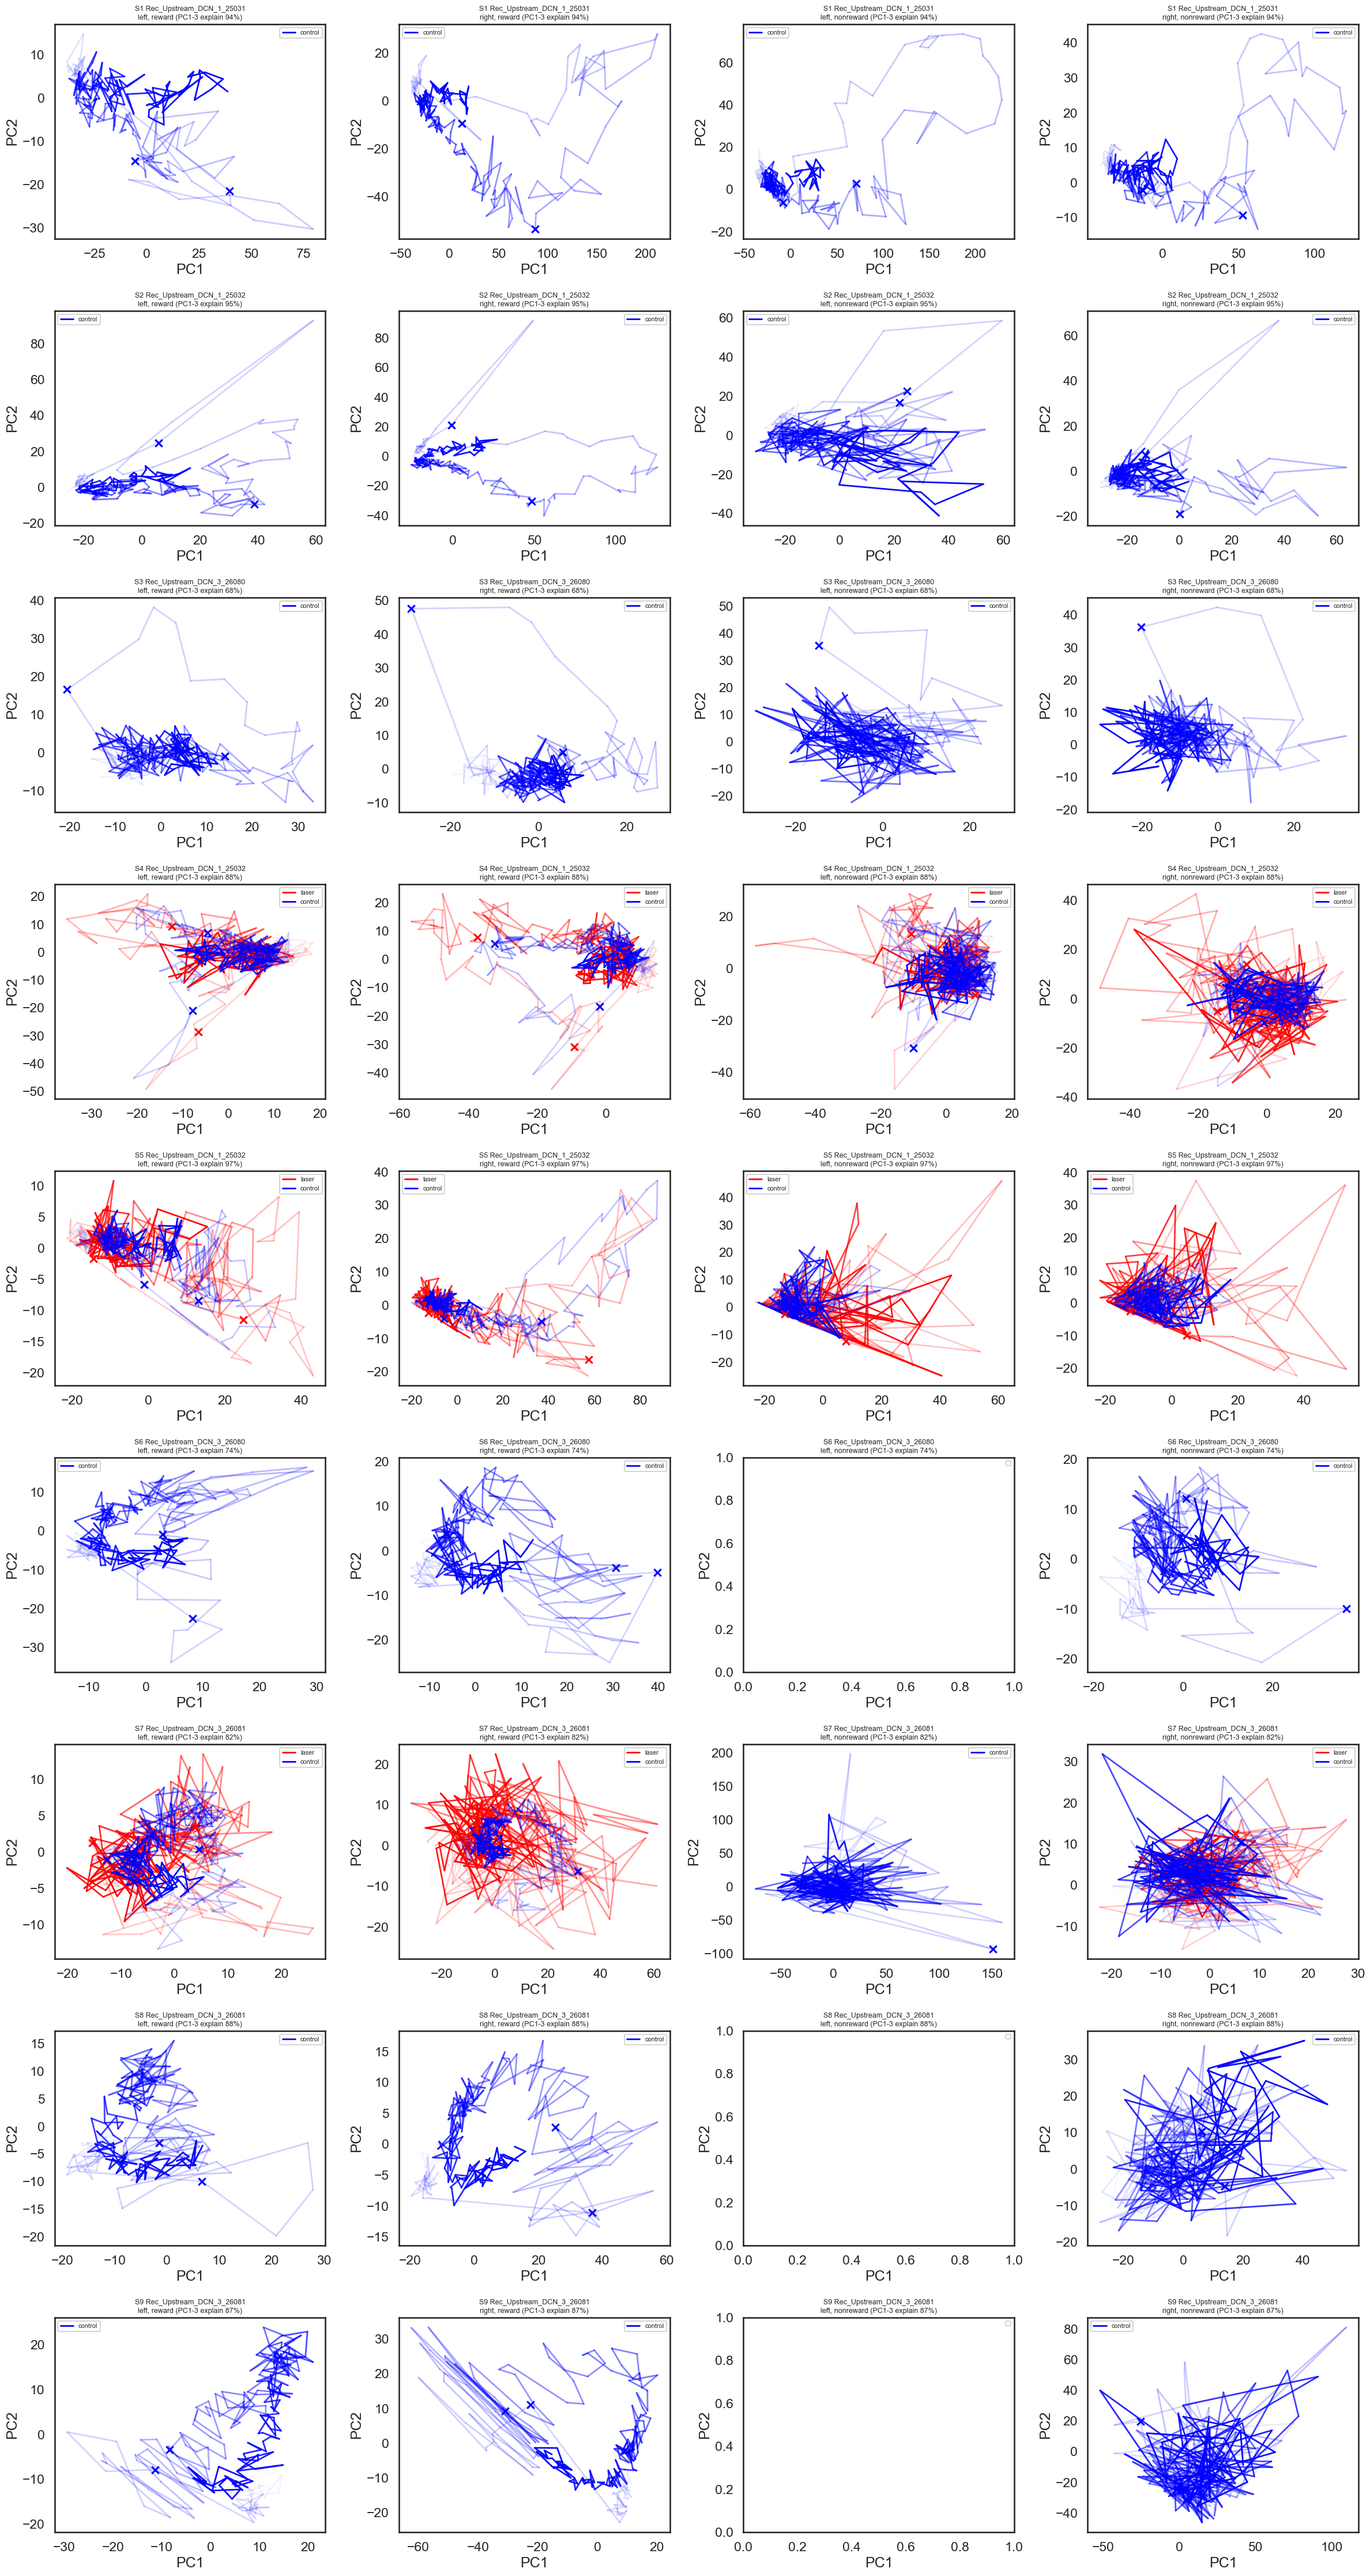

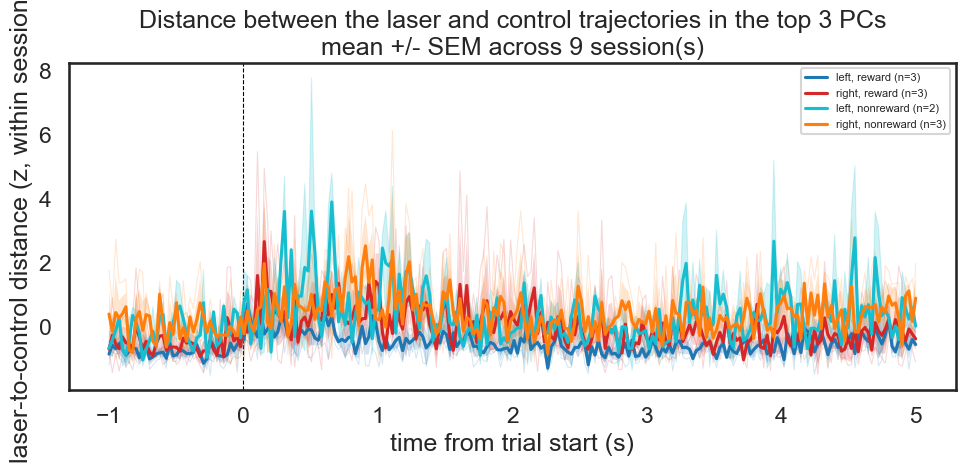

Variance explained per session:
   S1 Rec_Upstream_DCN_1_250318_CT_merged: PC1 87%, PC2 5%, PC3 3%
   S2 Rec_Upstream_DCN_1_250325_032525001: PC1 78%, PC2 12%, PC3 6%
   S3 Rec_Upstream_DCN_3_260802_080226001: PC1 41%, PC2 15%, PC3 12%
   S4 Rec_Upstream_DCN_1_250320_1mW_500ms_0delay_032025001: PC1 57%, PC2 23%, PC3 8%
   S5 Rec_Upstream_DCN_1_250322_5mW_50ms_0delay_032225001: PC1 87%, PC2 6%, PC3 5%
   S6 Rec_Upstream_DCN_3_260808_CT_080826001: PC1 39%, PC2 24%, PC3 11%
   S7 Rec_Upstream_DCN_3_260811_5mWBlue_500ms_081126001: PC1 56%, PC2 15%, PC3 11%
   S8 Rec_Upstream_DCN_3_260812_CT_081226001: PC1 60%, PC2 20%, PC3 8%
   S9 Rec_Upstream_DCN_3_260814_CT_081426001: PC1 53%, PC2 27%, PC3 7%


In [16]:
from sklearn.decomposition import PCA

n_pcs = 3
key_time = [0, 1]


def condition_matrix(sess, cond):
    """(bins, units) trial-averaged matrix, with any all-NaN bin filled by the unit mean"""
    rate = sess['aligned_trial_start'][cond]['rate']
    M = np.nanmean(np.asarray(rate, dtype=float), axis=1)
    M = M[criteria, :] if criteria is not None else M
    M = M.T
    if np.isnan(M).any():
        col_mean = np.nanmean(M, axis=0)
        M = np.nan_to_num(np.where(np.isnan(M), col_mean[None, :], M))
    return M


def session_pca(sess):
    """PCA fitted on that session's control trials, with every condition projected in"""
    control = condition_rates(sess, ['control'])
    X = np.nanmean(control, axis=1).T
    if np.isnan(X).any():
        col_mean = np.nanmean(X, axis=0)
        X = np.nan_to_num(np.where(np.isnan(X), col_mean[None, :], X))
    pca = PCA(n_components=min(n_pcs, X.shape[1])).fit(X)
    scores = {}
    for cond in CONDITIONS:
        scores[cond] = (pca.transform(condition_matrix(sess, cond))
                        if n_trials_in(sess, cond) else None)
    return pca, scores


per_session_pca = {}
for s in tqdm(sessions, desc='PCA'):
    per_session_pca[s['session_id']] = session_pca(s)

# ---- one 2x2 panel block per session ----
panel_conditions = [('reward_left', 'left, reward'), ('reward_right', 'right, reward'),
                    ('nonreward_left', 'left, nonreward'), ('nonreward_right', 'right, nonreward')]
fig, axs = plt.subplots(len(sessions), 4, figsize=(6 * 4, 5 * len(sessions)), squeeze=False)
for r, s in enumerate(sessions):
    pca, scores = per_session_pca[s['session_id']]
    for c, (stem, title) in enumerate(panel_conditions):
        ax = axs[r, c]
        for block, color in [('laser', 'red'), ('control', 'blue')]:
            sc = scores.get(f'{stem}_{block}')
            if sc is None:
                continue
            ndap.plot_pca(sc, color=color, ax=ax, label=block, key_time=key_time,
                          time_range=s['time_range'], bin_size_ms=s['bin_size'])
        ax.legend(fontsize=8)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        var = pca.explained_variance_ratio_
        ax.set_title(f"{s['tag']} {s['session_id'][:24]}\n{title} "
                     f"(PC1-{len(var)} explain {100*var.sum():.0f}%)", fontsize=9)
plt.tight_layout()
plt.show()

# ---- the one poolable curve: how far laser pulls the trajectory from control ----
distances = {}
for s in sessions:
    _, scores = per_session_pca[s['session_id']]
    per_cond = {}
    for stem, _ in panel_conditions:
        a, b = scores.get(f'{stem}_laser'), scores.get(f'{stem}_control')
        per_cond[stem] = (np.linalg.norm(a - b, axis=1) if a is not None and b is not None
                          else np.full(len(s['xaxis']), np.nan))
    distances[s['session_id']] = zscore_curves(per_cond)

fig, ax = plt.subplots(figsize=(10, 5))
for (stem, title), color in zip(panel_conditions, ['tab:blue', 'tab:red', 'tab:cyan', 'tab:orange']):
    pooled_sem_plot(ax, distances, stem, xaxis, color, 1.0, title)
ax.axvline(0, color='k', lw=0.8, ls='--', zorder=0)
ax.set_xlabel('time from trial start (s)')
ax.set_ylabel('laser-to-control distance (z, within session)')
ax.set_title(f'Distance between the laser and control trajectories in the top {n_pcs} PCs\n'
             f'mean +/- SEM across {len(sessions)} session(s)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Variance explained per session:")
for s in sessions:
    pca, _ = per_session_pca[s['session_id']]
    print(f"  {s['tag']:>3s} {s['session_id']}: "
          + ", ".join(f"PC{i+1} {100*v:.0f}%" for i, v in enumerate(pca.explained_variance_ratio_)))

## 4. Decoder analysis

### 4.1. Left and right axis

One decoder per session (a session's units are its own feature space), so what pools is
the accuracy-vs-time curve: mean +/- SEM across sessions, with each session faint
behind it. The chance line is fixed at 0.5 because `ndap.get_decoders` balances the
training set.

In [17]:
window_size = 100   # in ms


def session_decoder(sess, window_size_ms=window_size):
    """
    Left-vs-right logistic decoder trained on control trials, one per time window, plus
    the projection of all four conditions onto the best window's decoder.

    Returns {'accs','best','decoder','weights','proj'}; proj curves are z-scored
    together so they can be averaged across sessions.
    """
    blocks = {name: condition_rates(sess, keys) for name, keys in [
        ('left_control', ['left', 'control']), ('right_control', ['right', 'control']),
        ('left_laser', ['left', 'laser']), ('right_laser', ['right', 'laser'])]}

    if not blocks['left_control'].shape[1] or not blocks['right_control'].shape[1]:
        raise RuntimeError(f"{sess['session_id']}: no left/right control trials to train on")

    decoders, accs = ndap.get_decoders(blocks['left_control'], blocks['right_control'],
                                       window_size_ms=window_size_ms,
                                       bin_size_ms=sess['bin_size'], max_iter=10000)
    best = int(np.argmax(accs))
    decoder = decoders[best]

    proj = {}
    for name, block in blocks.items():
        proj[name] = (np.asarray(ndap.project(np.nanmean(block, axis=1), decoder), dtype=float)
                      if block.shape[1] else np.full(len(sess['xaxis']), np.nan))

    return dict(accs=np.asarray(accs, dtype=float), best=best, decoder=decoder,
                weights=np.asarray(decoder.coef_[0], dtype=float), proj=zscore_curves(proj))


per_session_decoder = {}
for s in tqdm(sessions, desc='decoders'):
    per_session_decoder[s['session_id']] = session_decoder(s)
    r = per_session_decoder[s['session_id']]
    print(f"  {s['tag']:>3s} {s['session_id']}: best accuracy {r['accs'][r['best']]:.3f} "
          f"in window {r['best']}")

decoders:   0%|          | 0/9 [00:00<?, ?it/s]

Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']


/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://sci

   S1 Rec_Upstream_DCN_1_250318_CT_merged: best accuracy 0.714 in window 11
Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']


decoders:  22%|██▏       | 2/9 [01:34<05:24, 46.32s/it]

...

   S7 Rec_Upstream_DCN_3_260811_5mWBlue_500ms_081126001: best accuracy 0.819 in window 20
Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']


decoders:  89%|████████▉ | 8/9 [03:26<00:16, 16.79s/it]

   S8 Rec_Upstream_DCN_3_260812_CT_081226001: best accuracy 0.940 in window 11
Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']


decoders: 100%|██████████| 9/9 [03:52<00:00, 25.78s/it]

   S9 Rec_Upstream_DCN_3_260814_CT_081426001: best accuracy 0.963 in window 13


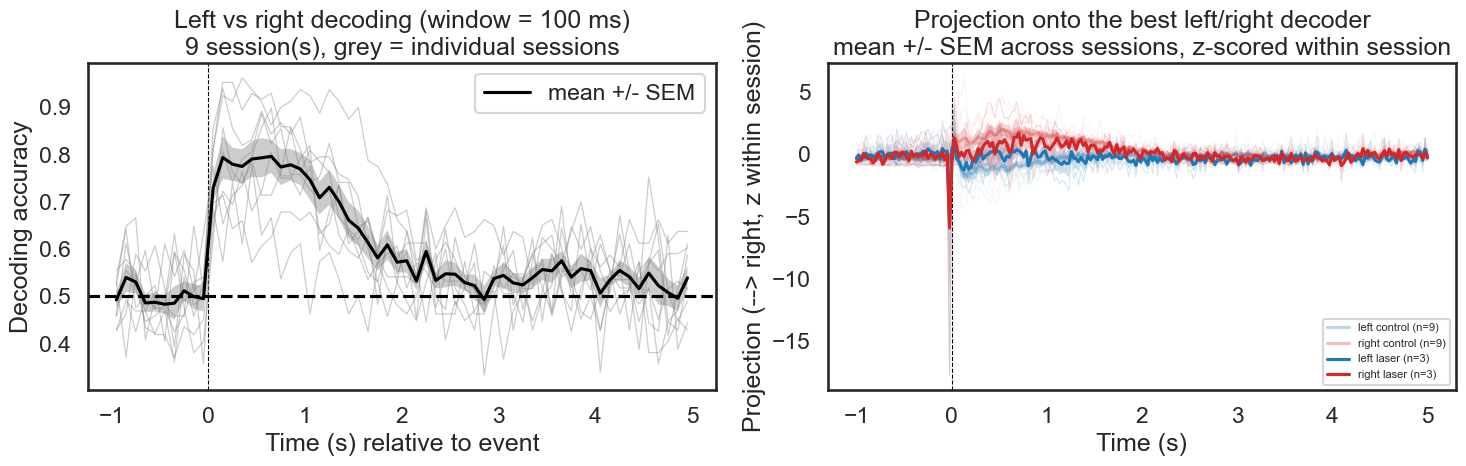

Peak accuracy across sessions: mean 0.868 +/- 0.028 SEM, range 0.714-0.963


In [18]:
# ---- accuracy vs time, and the projections, pooled across sessions ----
n_bins_full = len(xaxis)
window_size_in_bins = max(1, int(round(window_size / bin_size)))
acc_stack = np.vstack([per_session_decoder[s['session_id']]['accs'] for s in sessions])
n_windows = acc_stack.shape[1]

# window centres, from the same binning get_decoders used
time_bins = (np.linspace(time_range[0], time_range[1], n_bins_full, endpoint=False)
             + bin_size / 1000 / 2)
time_centers = np.array([
    time_bins[i * window_size_in_bins:min((i + 1) * window_size_in_bins, n_bins_full)].mean()
    for i in range(n_windows)])

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

for s in sessions:
    axs[0].plot(time_centers, per_session_decoder[s['session_id']]['accs'],
                color='gray', alpha=0.4, lw=0.9)
ndap.plot_sem(acc_stack, x=time_centers, color='black', ax=axs[0], label='mean +/- SEM')
axs[0].axhline(0.5, color='k', linestyle='--')
axs[0].axvline(0, color='k', lw=0.8, ls='--', zorder=0)
axs[0].set_xlabel('Time (s) relative to event')
axs[0].set_ylabel('Decoding accuracy')
axs[0].set_title(f'Left vs right decoding (window = {window_size} ms)\n'
                 f'{len(sessions)} session(s), grey = individual sessions')
axs[0].legend()

proj_curves = {sid: r['proj'] for sid, r in per_session_decoder.items()}
for name, color, alpha in [('left_control', left_color, alpha_ctrl),
                           ('right_control', right_color, alpha_ctrl),
                           ('left_laser', left_color, alpha_laser),
                           ('right_laser', right_color, alpha_laser)]:
    pooled_sem_plot(axs[1], proj_curves, name, xaxis, color, alpha, name.replace('_', ' '))
axs[1].axvline(0, color='k', lw=0.8, ls='--', zorder=0)
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Projection (--> right, z within session)')
axs[1].set_title('Projection onto the best left/right decoder\n'
                 'mean +/- SEM across sessions, z-scored within session')
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

peaks = acc_stack.max(axis=1)
if len(peaks) > 1:
    print(f"Peak accuracy across sessions: mean {peaks.mean():.3f} "
          f"+/- {peaks.std(ddof=1) / np.sqrt(len(peaks)):.3f} SEM, "
          f"range {peaks.min():.3f}-{peaks.max():.3f}")
else:
    print(f"Peak accuracy: {peaks[0]:.3f} (single session)")

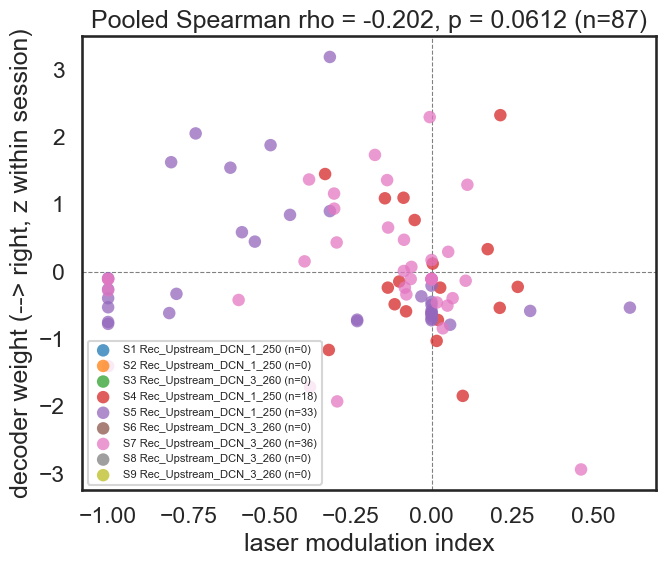

Per session (a pooled correlation can exist in none of them):
   S1 Rec_Upstream_DCN_1_250318_CT_merged: too few units (0)
   S2 Rec_Upstream_DCN_1_250325_032525001: too few units (0)
   S3 Rec_Upstream_DCN_3_260802_080226001: too few units (0)
   S4 Rec_Upstream_DCN_1_250320_1mW_500ms_0delay_032025001: rho -0.089, p 0.726, n 18
   S5 Rec_Upstream_DCN_1_250322_5mW_50ms_0delay_032225001: rho -0.315, p 0.0741, n 33
   S6 Rec_Upstream_DCN_3_260808_CT_080826001: too few units (0)
   S7 Rec_Upstream_DCN_3_260811_5mWBlue_500ms_081126001: rho -0.131, p 0.447, n 36
   S8 Rec_Upstream_DCN_3_260812_CT_081226001: too few units (0)
   S9 Rec_Upstream_DCN_3_260814_CT_081426001: too few units (0)


In [19]:
# Correlation of the decoder weights and the laser index, pooled over units.
# Weights are z-scored within session: their scale depends on that session's
# regularisation and unit count, so raw weights are not comparable across sessions.
from scipy.stats import spearmanr

w_units = np.concatenate([
    (lambda w: (w - w.mean()) / w.std() if w.std() > 0 else w * np.nan)(
        per_session_decoder[s['session_id']]['weights'])
    for s in sessions])

assert len(w_units) == len(units_table), 'decoder weights must line up with units_table'

ok = np.isfinite(w_units) & np.isfinite(laser_mod_index)
r_spear, p_spear = spearmanr(w_units[ok], laser_mod_index[ok])

fig, ax = plt.subplots(figsize=(7, 6))
for s in sessions:
    m = ok & (session_of_unit == s['session_id'])
    ax.scatter(laser_mod_index[m], w_units[m], alpha=0.75, edgecolor='none',
               label=f"{s['tag']} {s['session_id'][:22]} (n={int(m.sum())})")
ax.axhline(0, color='gray', lw=0.8, ls='--', zorder=0)
ax.axvline(0, color='gray', lw=0.8, ls='--', zorder=0)
ax.set_xlabel('laser modulation index')
ax.set_ylabel('decoder weight (--> right, z within session)')
ax.set_title(f"Pooled Spearman rho = {r_spear:.3f}, p = {p_spear:.3g} (n={int(ok.sum())})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Per session (a pooled correlation can exist in none of them):")
for s in sessions:
    m = ok & (session_of_unit == s['session_id'])
    if m.sum() < 5:
        print(f"  {s['tag']:>3s} {s['session_id']}: too few units ({int(m.sum())})")
        continue
    r, p = spearmanr(laser_mod_index[m], w_units[m])
    print(f"  {s['tag']:>3s} {s['session_id']}: rho {r:+.3f}, p {p:.3g}, n {int(m.sum())}")

## 5. rSLDS

An rSLDS fit is per session and expensive, and its latent space is only identified up
to a linear transform, so there is nothing to average: `rslds_session_ids` picks which
sessions to fit, each model is saved under its own session folder, and the results are
shown as one panel per session with the ELBO curves overlaid.

### 5.1 Prepare rSLDS data

Combining 2 conditions: ['nonreward_left_control', 'reward_left_control']
Combining 2 conditions: ['nonreward_right_control', 'reward_right_control']
[prepare_rslds_data] Data downsampled to 50 ms
[prepare_rslds_data] Data filled with 0 for nan
[prepare_rslds_data] Data z-scored
   S1 Rec_Upstream_DCN_1_250318_CT_merged: 138 left + 139 right control trials, 66 units


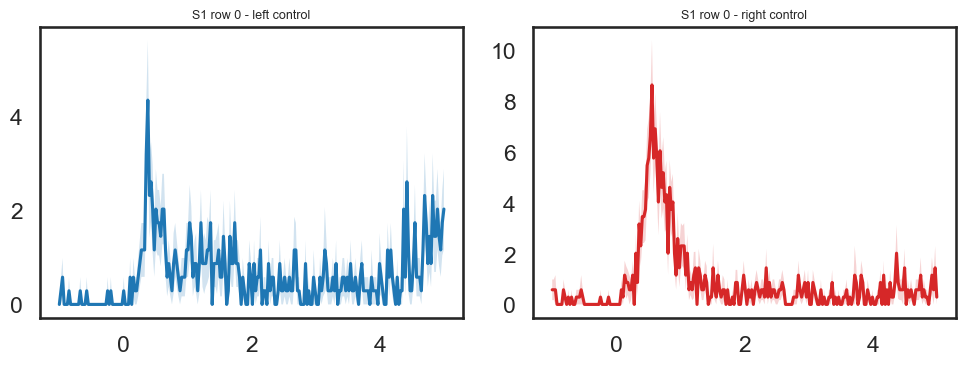

In [20]:
# Which sessions to fit. Fitting is minutes per session, so this defaults to the first
# one; set it to [s['session_id'] for s in sessions] to fit them all.
rslds_session_ids = [sessions[0]['session_id']]

target_bin_size_ms = 50
n_classes = 2

rslds_sessions = [s for s in sessions if s['session_id'] in rslds_session_ids]
if not rslds_sessions:
    raise RuntimeError(f"rslds_session_ids matches no loaded session: {rslds_session_ids}")

rslds_prepared = {}
for s in rslds_sessions:
    left_control = condition_rates(s, ['left', 'control'])
    right_control = condition_rates(s, ['right', 'control'])
    left_laser = condition_rates(s, ['left', 'laser'])
    right_laser = condition_rates(s, ['right', 'laser'])

    combined_data = np.concatenate([left_control, right_control], axis=1)
    type1_label = np.array([[1, 0]] * left_control.shape[1])
    type2_label = np.array([[0, 1]] * right_control.shape[1])
    trial_types = np.r_[type1_label, type2_label]

    rslds_data, inputs = ndap.prepare_rslds_data(
        combined_data, trial_types=trial_types, n_classes=n_classes, downsample=True,
        target_bin_size_ms=target_bin_size_ms, bin_size_ms=s['bin_size'])
    prepared = dict(data=rslds_data, inputs=inputs,
                    left_control=left_control, right_control=right_control)
    if left_laser.shape[1]:
        prepared['left_laser'] = ndap.prepare_rslds_data(
            left_laser, trial_types=np.array([[1, 0]] * left_laser.shape[1]),
            n_classes=n_classes, downsample=True,
            target_bin_size_ms=target_bin_size_ms, bin_size_ms=s['bin_size'])
    if right_laser.shape[1]:
        prepared['right_laser'] = ndap.prepare_rslds_data(
            right_laser, trial_types=np.array([[0, 1]] * right_laser.shape[1]),
            n_classes=n_classes, downsample=True,
            target_bin_size_ms=target_bin_size_ms, bin_size_ms=s['bin_size'])
    rslds_prepared[s['session_id']] = prepared
    print(f"  {s['tag']:>3s} {s['session_id']}: {left_control.shape[1]} left + "
          f"{right_control.shape[1]} right control trials, {left_control.shape[0]} units")

# sanity plot: one unit's left and right control PSTH in each prepared session
plot_unit = 0
fig, axes = plt.subplots(len(rslds_sessions), 2, figsize=(10, 4 * len(rslds_sessions)),
                         squeeze=False)
for r, s in enumerate(rslds_sessions):
    p = rslds_prepared[s['session_id']]
    ndap.plot_sem(p['left_control'][plot_unit], x=s['xaxis'], ax=axes[r, 0], color=left_color)
    ndap.plot_sem(p['right_control'][plot_unit], x=s['xaxis'], ax=axes[r, 1], color=right_color)
    axes[r, 0].set_title(f"{s['tag']} row {plot_unit} - left control", fontsize=9)
    axes[r, 1].set_title(f"{s['tag']} row {plot_unit} - right control", fontsize=9)
plt.tight_layout()
plt.show()

### 5.2. Fit a rSLDS model

In [21]:
# Set rSLDS parameters
n_states = 4         # Number of discrete states (change as appropriate)
n_latent_dims = 2    # Number of latent dimensions (for visualization)
num_iters = 50       # Number of EM iterations

rslds_fits = {}
for s in rslds_sessions:
    p = rslds_prepared[s['session_id']]
    print(f"fitting {s['session_id']}")
    rslds, posterior, elbos = ndap.fit_rslds_model(
        (p['data'], p['inputs']), n_states=n_states, n_latent_dims=n_latent_dims,
        num_iters=num_iters, emissions='gaussian')
    rslds_fits[s['session_id']] = dict(model=rslds, posterior=posterior, elbos=elbos)

fitting Rec_Upstream_DCN_1_250318_CT_merged
Initializing model...
Fitting rSLDS with laplace_em method...


ELBO: -2599243.9: 100%|██████████| 50/50 [04:01<00:00,  4.83s/it]

Fitting completed. Final ELBO: -2599243.88


In [22]:
# Save one model per session, each under its own session folder
rslds_paths = {}
for s in rslds_sessions:
    p, fit = rslds_prepared[s['session_id']], rslds_fits[s['session_id']]
    rslds_paths[s['session_id']] = ndap.save_rslds_model(
        fit['model'], fit['posterior'], (p['data'], p['inputs']),
        file_name="cue_-1to2.joblib", folder_name=s['session_id'],
        elbos=fit['elbos'], time_range=s['time_range'], bin_size=target_bin_size_ms)
    print(f"  {s['tag']:>3s} {s['session_id']}\n      -> {rslds_paths[s['session_id']]}")

   S1 Rec_Upstream_DCN_1_250318_CT_merged
      -> Results/rslds_models/Rec_Upstream_DCN_1_250318_CT_merged//cue_-1to2.joblib


### 5.3. Plot model

In [23]:
# Load the saved models. rslds_paths comes from the save cell above; to load models
# fitted in an earlier kernel, fill it in by hand:
# rslds_paths = {'Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001':
#                "Results/rslds_models/Rec_Upstream_DCN_1_250411_MixedmW_500ms_041225001/choice_-1to2.joblib"}

rslds_loaded = {}
for session_id, path in rslds_paths.items():
    B = ndap.load_rslds_model(path)
    type1_tuple, type2_tuple = ndap.separate_rslds_tuple(B["data"]["Y_list"], B["data"]["U_list"])
    rslds_loaded[session_id] = dict(
        model=B["objects"]["model"], posterior=B["objects"]["posterior"],
        elbos=B["posterior"]["elbos"], time_range=B["data"]["time_range"],
        bin_size=B["data"]["bin_size"], type1=type1_tuple, type2=type2_tuple)
    print(f"  loaded {session_id} from {path}")

  loaded Rec_Upstream_DCN_1_250318_CT_merged from Results/rslds_models/Rec_Upstream_DCN_1_250318_CT_merged//cue_-1to2.joblib


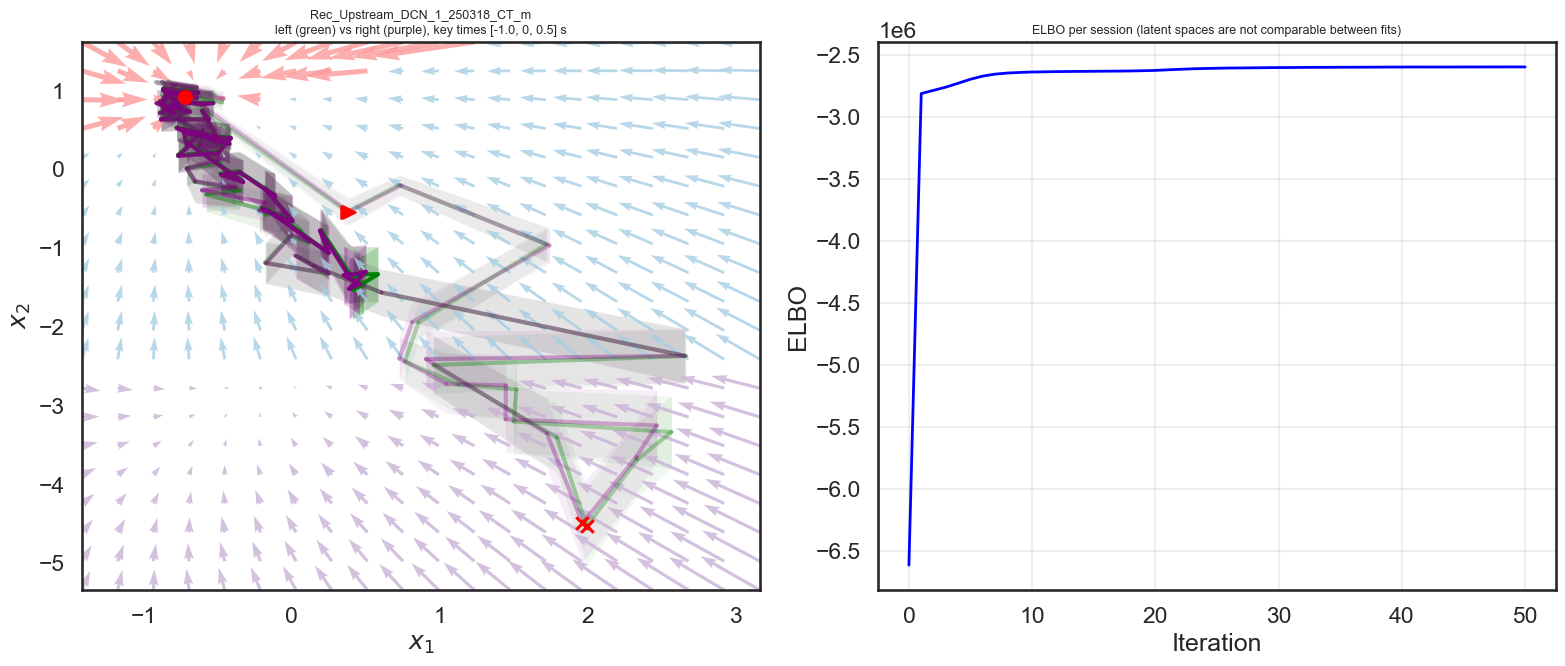

In [24]:
# One trajectory panel per session, with every ELBO curve in the last panel.
fig, axes = plt.subplots(1, len(rslds_loaded) + 1,
                         figsize=(8 * (len(rslds_loaded) + 1), 7), squeeze=False)
axes = axes[0]

# Select trial indices (None = all trials)
t1_idx = None
t2_idx = None

for ax, (session_id, r) in zip(axes, rslds_loaded.items()):
    key_time = [r['time_range'][0], 0, 0.5]
    ndap.plot_rslds_trajectory(r['model'], r['posterior'], r['type1'], ax=ax, trial_idx=t1_idx,
                               color="green", key_time=key_time,
                               time_range=r['time_range'], bin_size=r['bin_size'])
    ndap.plot_rslds_trajectory(r['model'], r['posterior'], r['type2'], ax=ax, trial_idx=t2_idx,
                               color="purple", key_time=key_time,
                               time_range=r['time_range'], bin_size=r['bin_size'])
    ndap.plot_rslds_dynamics(r['model'], ax=ax)
    ax.set_title(f"{session_id[:30]}\nleft (green) vs right (purple), "
                 f"key times {key_time} s", fontsize=9)

for session_id, r in rslds_loaded.items():
    ndap.plot_rslds_elbo(r['elbos'], ax=axes[-1])
axes[-1].set_title('ELBO per session (latent spaces are not comparable between fits)',
                   fontsize=9)

plt.tight_layout()
plt.show()

## Close files

Every loaded session holds an open HDF5 handle. Close them before re-running
`analyze_sessions_forPlexon.py`, which cannot overwrite a file this kernel still has open.

In [25]:
for s in sessions:
    ndap.close_loaded(s['data'])
    ndap.close_loaded(s['aligned_spikes'])
print(f"closed {len(sessions)} session file handle pair(s)")

closed 9 session file handle pair(s)
